<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_8_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For each function, I will follow this sequence:

1. Load the week_8_dataset
2. Extract function 1
2. Check shapes and missing values
3. Calculate summary statistics
4. Plot the output trend
5. Plot the best-so-far trend
6. identify the best query point
7. Plot the correlation heatmap
8. Plot each input against the output
9. Fit a Gaussian Process surrogate
10. Apply UCB to generate the next query point

In [127]:
# ============================================================
# UNZIP WEEK 8 DATASET
# ============================================================

import zipfile
import os

zip_path = "/content/week_8_data.zip"
extract_path = "/content/week_8_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Week 8 dataset unzipped successfully.")

Week 8 dataset unzipped successfully.


In [128]:
import os

os.listdir("/content/week_8_dataset")

['function_2_outputs.npy',
 'function_3_outputs.npy',
 'function_6_outputs.npy',
 'function_5_outputs.npy',
 'function_7_inputs.npy',
 'function_1_outputs.npy',
 'function_6_inputs.npy',
 'function_4_outputs.npy',
 'function_5_inputs.npy',
 'function_3_inputs.npy',
 'function_2_inputs.npy',
 'function_8_inputs.npy',
 'function_8_outputs.npy',
 'function_1_inputs.npy',
 'function_7_outputs.npy',
 'function_4_inputs.npy']

In [129]:
# Print the shapes of all Functions

import os
import numpy as np

week_8_path = "/content/week_8_dataset"

for i in range(1, 9):
    X = np.load(os.path.join(week_8_path, f"function_{i}_inputs.npy"))
    y = np.load(os.path.join(week_8_path, f"function_{i}_outputs.npy"))

    print(f"Function {i}")
    print(f"Input shape:  {X.shape}")
    print(f"Output shape: {y.shape}")
    print("-" * 40)

Function 1
Input shape:  (17, 2)
Output shape: (17,)
----------------------------------------
Function 2
Input shape:  (17, 2)
Output shape: (17,)
----------------------------------------
Function 3
Input shape:  (22, 3)
Output shape: (22,)
----------------------------------------
Function 4
Input shape:  (37, 4)
Output shape: (37,)
----------------------------------------
Function 5
Input shape:  (27, 4)
Output shape: (27,)
----------------------------------------
Function 6
Input shape:  (27, 5)
Output shape: (27,)
----------------------------------------
Function 7
Input shape:  (37, 6)
Output shape: (37,)
----------------------------------------
Function 8
Input shape:  (46, 8)
Output shape: (47,)
----------------------------------------


In [130]:
week_8_path = "/content/week_8_dataset"

***FUNCTION 1 FOR WEEK 8***

In [131]:
# ============================================================
# FUNCTION 1 — LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import Matern

# Week 8 dataset path
week_8_path = "/content/week_8_dataset"

# Function number and dimensions
f = 1
dim = 2

# Load Function 1 inputs
X1 = np.load(
    week_8_path + "/function_1_inputs.npy",
    allow_pickle=True
)

# Load Function 1 outputs
y1 = np.load(
    week_8_path + "/function_1_outputs.npy",
    allow_pickle=True
)

# Convert to clean numerical arrays
X1 = np.asarray(X1, dtype=float).reshape(-1, dim)
y1 = np.asarray(y1, dtype=float).reshape(-1)

print("Function 1 loaded successfully.")
print("X1 shape:", X1.shape)
print("y1 shape:", y1.shape)

Function 1 loaded successfully.
X1 shape: (17, 2)
y1 shape: (17,)


In [132]:
# ============================================================
# FUNCTION 1 — SHAPES AND MISSING VALUES
# ============================================================

print("Input shape:", X1.shape)
print("Output shape:", y1.shape)

print("\nNumber of input rows:", X1.shape[0])
print("Number of input variables:", X1.shape[1])
print("Number of output values:", len(y1))

print("\nMissing values in X1:", np.isnan(X1).sum())
print("Missing values in y1:", np.isnan(y1).sum())

print("\nInfinite values in X1:", np.isinf(X1).sum())
print("Infinite values in y1:", np.isinf(y1).sum())

# Confirm that every input point has an output
if len(X1) == len(y1):
    print("\nCheck passed: every input point has a corresponding output.")
else:
    print("\nWarning: the numbers of inputs and outputs do not match.")

Input shape: (17, 2)
Output shape: (17,)

Number of input rows: 17
Number of input variables: 2
Number of output values: 17

Missing values in X1: 0
Missing values in y1: 0

Infinite values in X1: 0
Infinite values in y1: 0

Check passed: every input point has a corresponding output.


In [133]:
# ============================================================
# FUNCTION 1 — CREATE DATAFRAME
# ============================================================

function_1_df = pd.DataFrame({
    "Query_Number": np.arange(1, len(y1) + 1),
    "x1": X1[:, 0],
    "x2": X1[:, 1],
    "Output": y1
})

function_1_df

,Query_Number,x1,x2,Output
0,1,0.319404,0.762959,1.322677e-79
1,2,0.574329,0.879898,1.033078e-46
2,3,0.731024,0.733000,7.710875e-16
3,4,0.840353,0.264732,3.341771e-124
4,5,0.650114,0.681526,-3.606063e-03
5,6,0.410437,0.147554,-2.159249e-54
6,7,0.312691,0.078723,-2.089093e-91
7,8,0.683418,0.861057,2.535001e-40
8,9,0.082507,0.403488,3.606771e-81
9,10,0.883890,0.582254,6.229856e-48


In [134]:
# ============================================================
# FUNCTION 1 — SUMMARY STATISTICS
# ============================================================

print("FUNCTION 1 SUMMARY STATISTICS")
print("-" * 50)

print(function_1_df[["x1", "x2", "Output"]].describe())

print("\nMinimum output:", np.min(y1))
print("Maximum output:", np.max(y1))
print("Mean output:", np.mean(y1))
print("Median output:", np.median(y1))
print("Output standard deviation:", np.std(y1))

FUNCTION 1 SUMMARY STATISTICS
--------------------------------------------------
              x1         x2         Output
count  17.000000  17.000000   1.700000e+01
mean    0.537187   0.609470   1.505861e+01
std     0.250809   0.354660   2.798331e+01
min     0.082507   0.078723  -3.606063e-03
25%     0.374540   0.264732  7.651210e-239
50%     0.410437   0.733000   1.322677e-79
75%     0.731024   0.950714   7.710875e-16
max     0.897714   0.999543   6.400000e+01

Minimum output: -0.0036060626443634764
Maximum output: 64.0
Mean output: 15.058611408079743
Median output: 1.3226770395454077e-79
Output standard deviation: 27.147797868477774


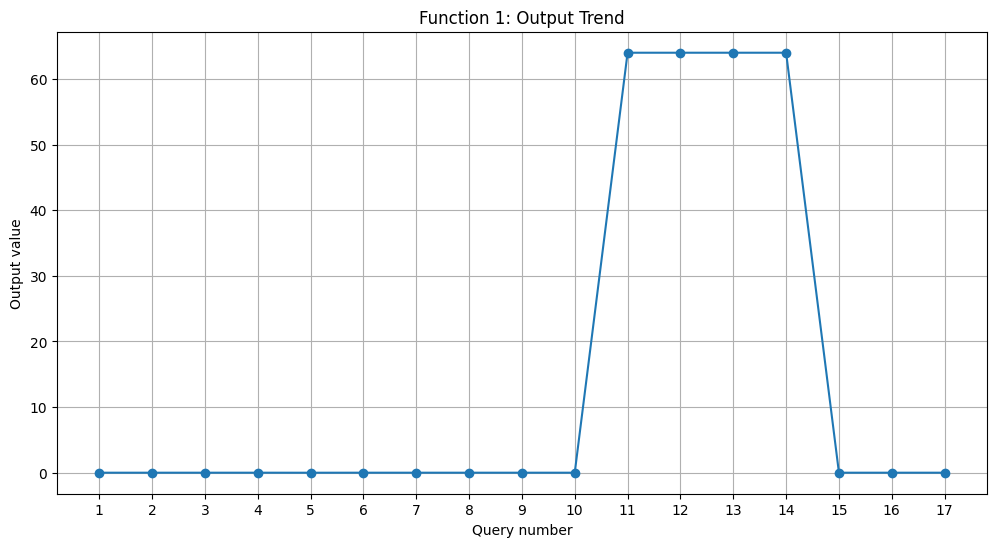

In [135]:
# ============================================================
# FUNCTION 1 — OUTPUT TREND
# ============================================================

query_numbers = np.arange(1, len(y1) + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    y1,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Output value")
plt.title("Function 1: Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

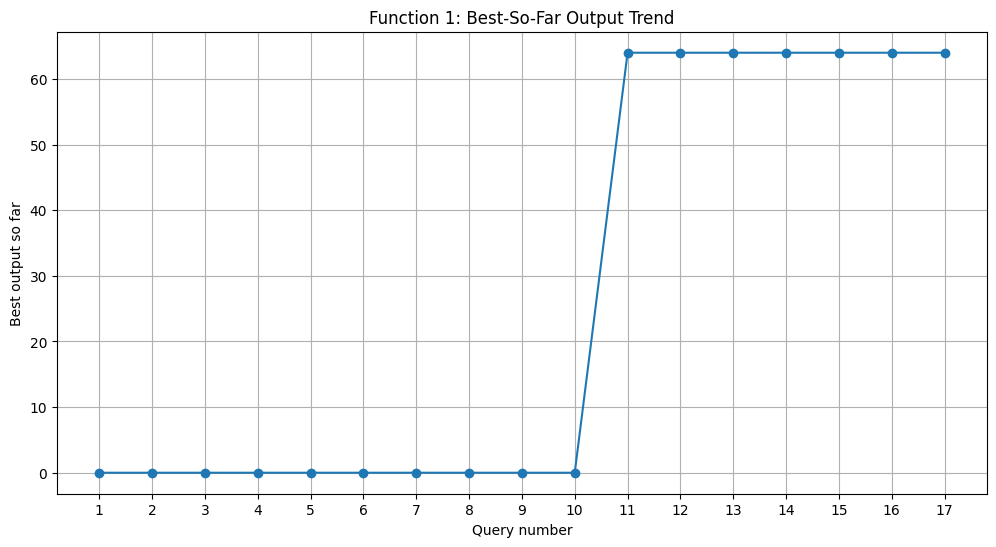

In [136]:
# ============================================================
# FUNCTION 1 — BEST-SO-FAR OUTPUT TREND
# ============================================================

best_so_far_1 = np.maximum.accumulate(y1)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    best_so_far_1,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Best output so far")
plt.title("Function 1: Best-So-Far Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

In [137]:
# ============================================================
# FUNCTION 1 — BEST QUERY POINT
# ============================================================

best_index_1 = np.argmax(y1)

best_query_number_1 = best_index_1 + 1
best_input_1 = X1[best_index_1]
best_output_1 = y1[best_index_1]

print("Best query number:", best_query_number_1)
print("Best input point:", best_input_1)
print("Best x1 value:", best_input_1[0])
print("Best x2 value:", best_input_1[1])
print("Best output value:", best_output_1)

Best query number: 11
Best input point: [0.37454  0.950714]
Best x1 value: 0.37454
Best x2 value: 0.950714
Best output value: 64.0


In [138]:
function_1_df.sort_values("Output", ascending=False).head(10)

,Query_Number,x1,x2,Output
13,14,0.374540,0.950714,6.400000e+01
11,12,0.374540,0.950714,6.400000e+01
12,13,0.374540,0.950714,6.400000e+01
10,11,0.374540,0.950714,6.400000e+01
2,3,0.731024,0.733000,7.710875e-16
7,8,0.683418,0.861057,2.535001e-40
1,2,0.574329,0.879898,1.033078e-46
9,10,0.883890,0.582254,6.229856e-48
0,1,0.319404,0.762959,1.322677e-79
8,9,0.082507,0.403488,3.606771e-81


              x1        x2    Output
x1      1.000000 -0.332004 -0.370789
x2     -0.332004  1.000000  0.550139
Output -0.370789  0.550139  1.000000


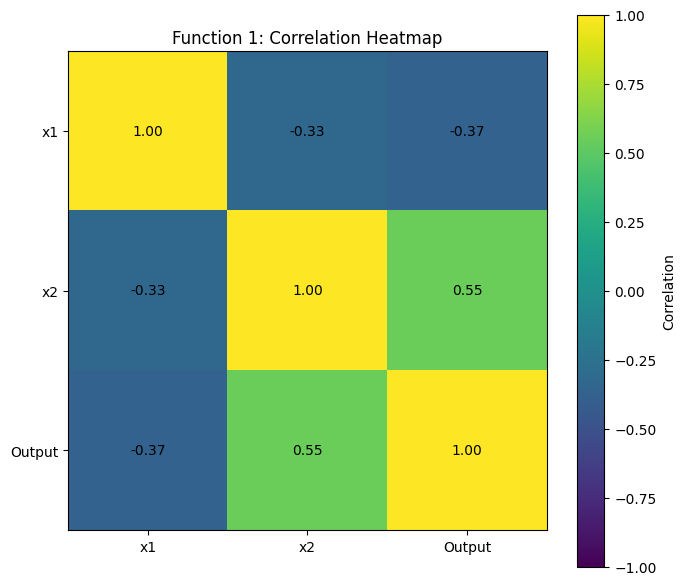

In [139]:
# ============================================================
# FUNCTION 1 — CORRELATION HEATMAP
# ============================================================

correlation_1 = function_1_df[
    ["x1", "x2", "Output"]
].corr()

print(correlation_1)

plt.figure(figsize=(7, 6))

plt.imshow(
    correlation_1,
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_1.columns)),
    correlation_1.columns
)

plt.yticks(
    range(len(correlation_1.columns)),
    correlation_1.columns
)

# Display correlation numbers inside the heatmap
for i in range(len(correlation_1.columns)):
    for j in range(len(correlation_1.columns)):
        plt.text(
            j,
            i,
            f"{correlation_1.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Function 1: Correlation Heatmap")
plt.tight_layout()
plt.show()

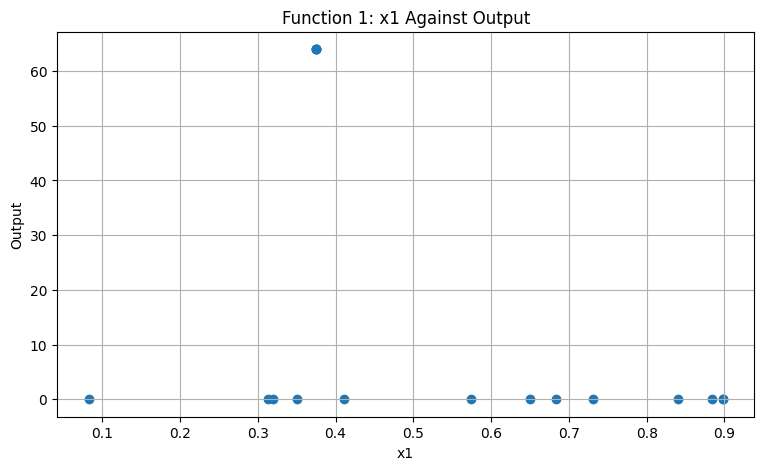

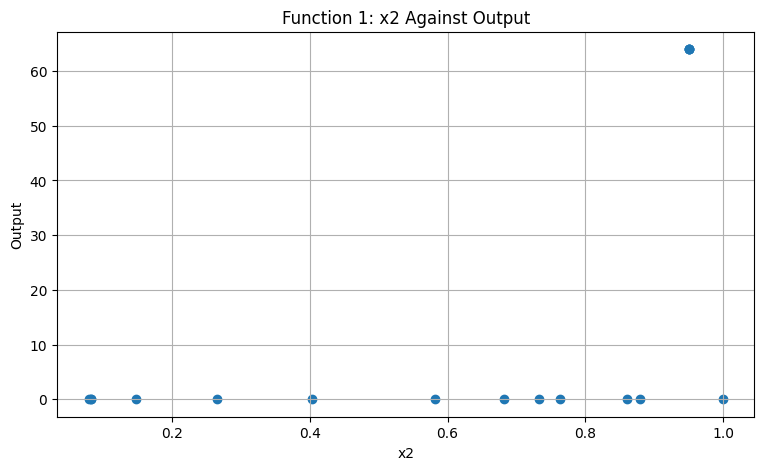

In [140]:
# ============================================================
# FUNCTION 1 — INPUT-OUTPUT SCATTER PLOTS
# ============================================================

# x1 against output
plt.figure(figsize=(9, 5))

plt.scatter(
    X1[:, 0],
    y1
)

plt.xlabel("x1")
plt.ylabel("Output")
plt.title("Function 1: x1 Against Output")
plt.grid(True)
plt.show()


# x2 against output
plt.figure(figsize=(9, 5))

plt.scatter(
    X1[:, 1],
    y1
)

plt.xlabel("x2")
plt.ylabel("Output")
plt.title("Function 1: x2 Against Output")
plt.grid(True)
plt.show()

In [141]:
# ============================================================
# FUNCTION 1 — INITIALISE AND FIT GP
# ============================================================

# RBF kernel settings
length_scale_1 = np.array([0.05,0.05])

kernel_1 = RBF(
    length_scale=length_scale_1,
    length_scale_bounds="fixed"
)

# Gaussian Process surrogate model
gp_1 = GaussianProcessRegressor(
    kernel=kernel_1,
    alpha=1e-4,
    normalize_y=True
)

# Fit the surrogate model using the Week 8 observations
gp_1.fit(X1, y1)

print("Gaussian Process fitted successfully for Function 1.")
print("Kernel:", gp_1.kernel_)

Gaussian Process fitted successfully for Function 1.
Kernel: RBF(length_scale=[0.05, 0.05])


In [142]:
# ============================================================
# FUNCTION 1 — GENERATE CANDIDATE POINTS
# ============================================================

# Fix the random seed so that the same candidates are generated
np.random.seed(42)

num_candidates = 10000

candidate_X1 = np.random.uniform(
    low=0.0,
    high=1.0,
    size=(num_candidates, dim)
)

print("Candidate shape:", candidate_X1.shape)
print("\nFirst five candidate points:")
print(candidate_X1[:5])

Candidate shape: (10000, 2)

First five candidate points:
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]]


In [143]:
# ============================================================
# FUNCTION 1 — UCB ACQUISITION FUNCTION
# ============================================================

# UCB exploration parameter
kappa = 1.5

# GP predictions for all candidate points
predicted_mean_1, predicted_std_1 = gp_1.predict(
    candidate_X1,
    return_std=True
)

# Upper Confidence Bound
ucb_1 = predicted_mean_1 + kappa * predicted_std_1

print("UCB calculated successfully.")
print("Number of UCB scores:", len(ucb_1))

UCB calculated successfully.
Number of UCB scores: 10000


In [144]:
# ============================================================
# FUNCTION 1 — SELECT NEXT QUERY POINT
# ============================================================

next_index_1 = np.argmax(ucb_1)

next_query_1 = candidate_X1[next_index_1]
next_mean_1 = predicted_mean_1[next_index_1]
next_std_1 = predicted_std_1[next_index_1]
next_ucb_1 = ucb_1[next_index_1]

print("FUNCTION 1 NEXT QUERY")
print("-" * 50)

print("Selected query point:")
print(next_query_1)

print("\nx1:", next_query_1[0])
print("x2:", next_query_1[1])

print("\nGP predicted mean:", next_mean_1)
print("GP predicted uncertainty:", next_std_1)
print("UCB score:", next_ucb_1)

FUNCTION 1 NEXT QUERY
--------------------------------------------------
Selected query point:
[0.39783663 0.91953102]

x1: 0.3978366255021569
x2: 0.9195310246560497

GP predicted mean: 65.1466470476859
GP predicted uncertainty: 16.687031667869384
UCB score: 90.17719454948998


In [145]:
# ============================================================
# FUNCTION 1 — SUBMISSION FORMAT
# ============================================================

print(
    f"Function 1 query: "
    f"[{next_query_1[0]:.6f}-{next_query_1[1]:.6f}]"
)

Function 1 query: [0.397837-0.919531]


***FUNCTION 2 FOR WEEK 8***

In [146]:
# ============================================================
# FUNCTION 2 — LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Week 8 dataset path
week_8_path = "/content/week_8_dataset"

# Function number and dimensions
f = 2
dim = 2

# Load Function 2 inputs
X1 = np.load(
    week_8_path + "/function_2_inputs.npy",
    allow_pickle=True
)

# Load Function 2 outputs
y1 = np.load(
    week_8_path + "/function_2_outputs.npy",
    allow_pickle=True
)

# Convert to clean numerical arrays
X1 = np.asarray(X1, dtype=float).reshape(-1, dim)
y1 = np.asarray(y1, dtype=float).reshape(-1)

print("Function 2 loaded successfully.")
print("X1 shape:", X1.shape)
print("y1 shape:", y1.shape)

Function 2 loaded successfully.
X1 shape: (17, 2)
y1 shape: (17,)


In [147]:
# ============================================================
# FUNCTION 2 — SHAPES AND MISSING VALUES
# ============================================================

print("Input shape:", X1.shape)
print("Output shape:", y1.shape)

print("\nNumber of input rows:", X1.shape[0])
print("Number of input variables:", X1.shape[1])
print("Number of output values:", len(y1))

print("\nMissing values in X1:", np.isnan(X1).sum())
print("Missing values in y1:", np.isnan(y1).sum())

print("\nInfinite values in X1:", np.isinf(X1).sum())
print("Infinite values in y1:", np.isinf(y1).sum())

# Confirm that every input point has an output
if len(X1) == len(y1):
    print("\nCheck passed: every input point has a corresponding output.")
else:
    print("\nWarning: the numbers of inputs and outputs do not match.")

Input shape: (17, 2)
Output shape: (17,)

Number of input rows: 17
Number of input variables: 2
Number of output values: 17

Missing values in X1: 0
Missing values in y1: 0

Infinite values in X1: 0
Infinite values in y1: 0

Check passed: every input point has a corresponding output.


In [148]:
# ============================================================
# FUNCTION 2 — CREATE DATAFRAME
# ============================================================

function_2_df = pd.DataFrame({
    "Query_Number": np.arange(1, len(y1) + 1),
    "x1": X1[:, 0],
    "x2": X1[:, 1],
    "Output": y1
})

function_2_df

,Query_Number,x1,x2,Output
0,1,0.665800,0.123969,5.389961e-01
1,2,0.877791,0.778628,4.205862e-01
2,3,0.142699,0.349005,-6.562362e-02
3,4,0.845275,0.711120,2.939929e-01
4,5,0.454647,0.290455,2.149645e-01
5,6,0.577713,0.771973,2.310555e-02
6,7,0.438166,0.685018,2.446193e-01
7,8,0.341750,0.028698,3.874902e-02
8,9,0.338648,0.213867,-1.385762e-02
9,10,0.702637,0.926564,6.112052e-01


In [149]:
# ============================================================
# FUNCTION 2 — SUMMARY STATISTICS
# ============================================================

print("FUNCTION 2 SUMMARY STATISTICS")
print("-" * 50)

print(function_2_df[["x1", "x2", "Output"]].describe())

print("\nMinimum output:", np.min(y1))
print("Maximum output:", np.max(y1))
print("Mean output:", np.mean(y1))
print("Median output:", np.median(y1))
print("Output standard deviation:", np.std(y1))

FUNCTION 2 SUMMARY STATISTICS
--------------------------------------------------
              x1         x2         Output
count  17.000000  17.000000   1.700000e+01
mean    0.470801   0.611994   3.929236e+00
std     0.225854   0.336561   1.548120e+01
min     0.009675   0.028698  -6.562362e-02
25%     0.374540   0.349005 -1.560647e-117
50%     0.438166   0.711120   2.149645e-01
75%     0.577713   0.950714   2.939929e-01
max     0.877791   0.999881   6.400000e+01

Minimum output: -0.06562362443733738
Maximum output: 64.0
Mean output: 3.9292360882921606
Median output: 0.2149645101004509
Output standard deviation: 15.018965697865847


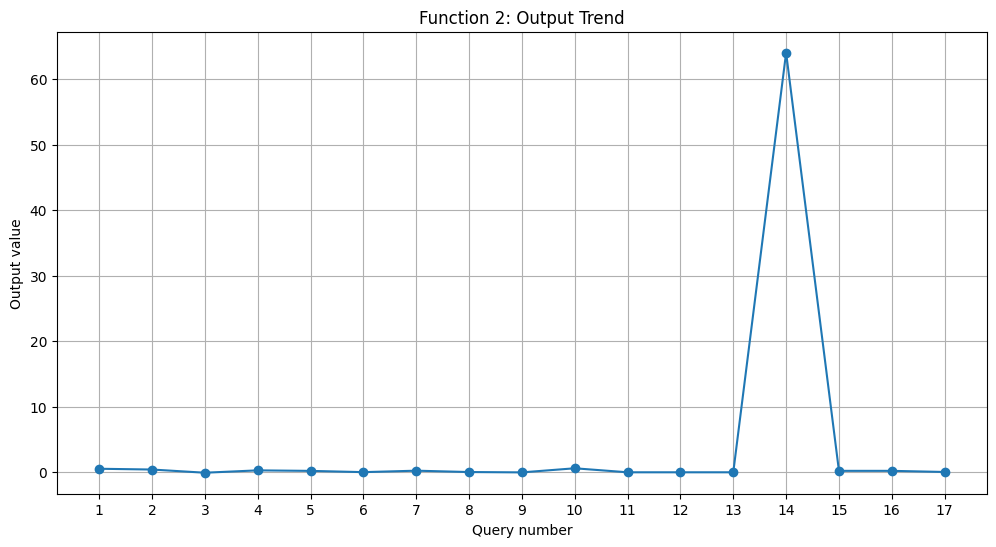

In [150]:
# ============================================================
# FUNCTION 2 — OUTPUT TREND
# ============================================================

query_numbers = np.arange(1, len(y1) + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    y1,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Output value")
plt.title("Function 2: Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

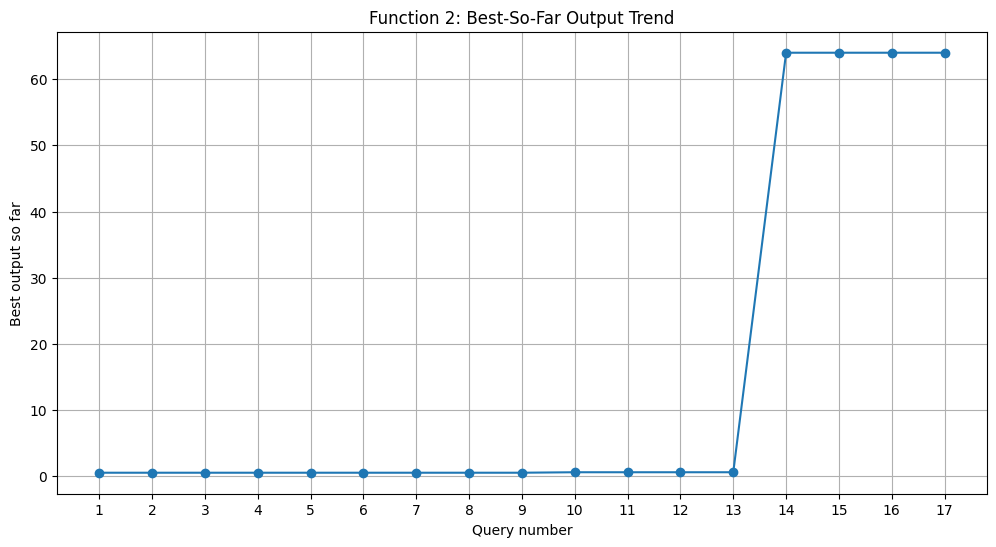

In [151]:
# ============================================================
# FUNCTION 2 — BEST-SO-FAR OUTPUT TREND
# ============================================================

best_so_far_2 = np.maximum.accumulate(y1)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    best_so_far_2,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Best output so far")
plt.title("Function 2: Best-So-Far Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

              x1        x2    Output
x1      1.000000 -0.028727 -0.100251
x2     -0.028727  1.000000  0.258705
Output -0.100251  0.258705  1.000000


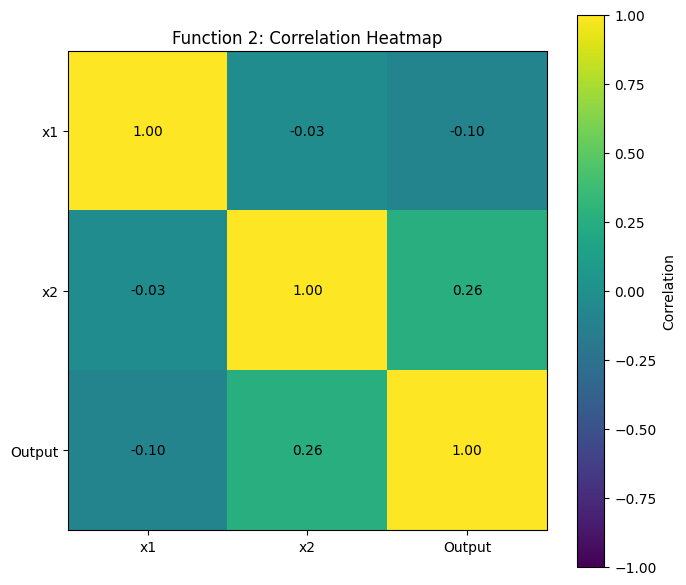

In [152]:
# ============================================================
# FUNCTION 2 — CORRELATION HEATMAP
# ============================================================

correlation_2 = function_2_df[
    ["x1", "x2", "Output"]
].corr()

print(correlation_2)

plt.figure(figsize=(7, 6))

plt.imshow(
    correlation_2,
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_2.columns)),
    correlation_2.columns
)

plt.yticks(
    range(len(correlation_2.columns)),
    correlation_2.columns
)

# Display correlation numbers inside the heatmap
for i in range(len(correlation_2.columns)):
    for j in range(len(correlation_2.columns)):
        plt.text(
            j,
            i,
            f"{correlation_2.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Function 2: Correlation Heatmap")
plt.tight_layout()
plt.show()

In [153]:
# ============================================================
# FUNCTION 2 — BEST QUERY POINT
# ============================================================

best_index_2 = np.argmax(y1)

best_query_number_2 = best_index_2 + 1
best_input_2 = X1[best_index_2]
best_output_2 = y1[best_index_2]

print("Best query number:", best_query_number_2)
print("Best input point:", best_input_2)
print("Best x1 value:", best_input_2[0])
print("Best x2 value:", best_input_2[1])
print("Best output value:", best_output_2)

Best query number: 14
Best input point: [0.37454  0.950714]
Best x1 value: 0.37454
Best x2 value: 0.950714
Best output value: 64.0


In [154]:
function_2_df.sort_values("Output", ascending=False).head(10)

,Query_Number,x1,x2,Output
13,14,0.374540,0.950714,64.000000
9,10,0.702637,0.926564,0.611205
0,1,0.665800,0.123969,0.538996
1,2,0.877791,0.778628,0.420586
3,4,0.845275,0.711120,0.293993
6,7,0.438166,0.685018,0.244619
14,15,0.555332,0.360931,0.220781
15,16,0.555332,0.360931,0.220781
4,5,0.454647,0.290455,0.214965
16,17,0.009675,0.999881,0.048714


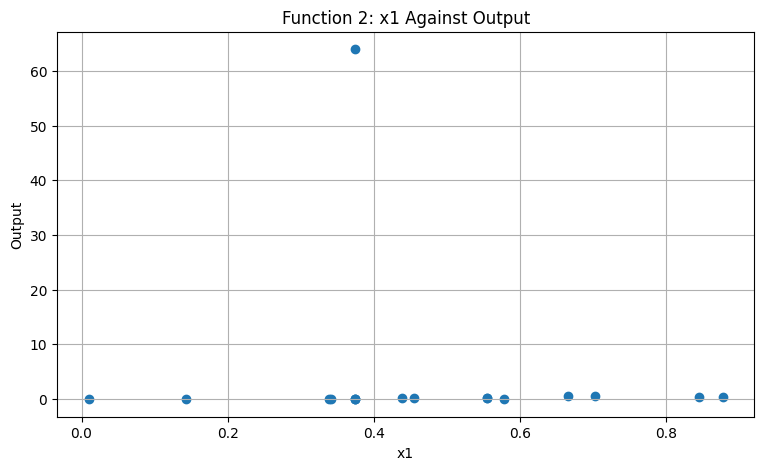

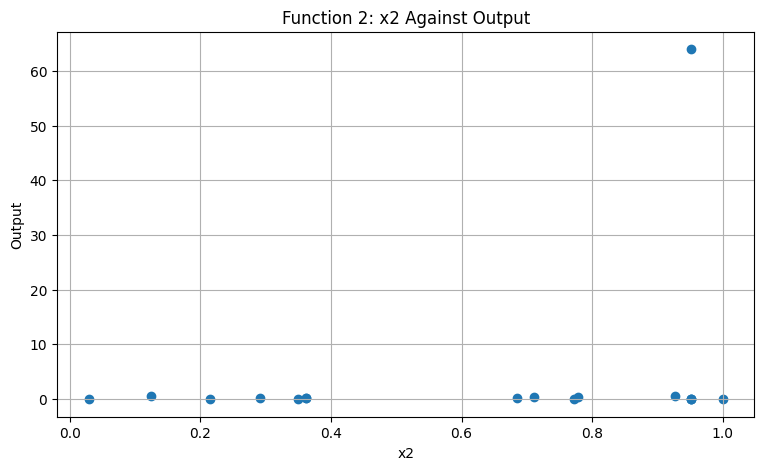

In [155]:
# ============================================================
# FUNCTION 2 — INPUT-OUTPUT SCATTER PLOTS
# ============================================================

# x1 against output
plt.figure(figsize=(9, 5))

plt.scatter(
    X1[:, 0],
    y1
)

plt.xlabel("x1")
plt.ylabel("Output")
plt.title("Function 2: x1 Against Output")
plt.grid(True)
plt.show()


# x2 against output
plt.figure(figsize=(9, 5))

plt.scatter(
    X1[:, 1],
    y1
)

plt.xlabel("x2")
plt.ylabel("Output")
plt.title("Function 2: x2 Against Output")
plt.grid(True)
plt.show()

In [156]:
# ============================================================
# FUNCTION 2 — INITIALISE AND FIT GP
# ============================================================

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
# RBF kernel settings
length_scale_1 = np.array([0.05,0.05])

kernel_1 = Matern(
    length_scale=length_scale_1,
    length_scale_bounds="fixed",
    nu=2.5
)

# Gaussian Process surrogate model
gp_2 = GaussianProcessRegressor(
    kernel=kernel_1,
    alpha=1e-4,
    normalize_y=True
)

# Fit the surrogate model using the Week 8 observations
gp_2.fit(X1, y1)

print("Gaussian Process fitted successfully for Function 2.")
print("Kernel:", gp_2.kernel_)

Gaussian Process fitted successfully for Function 2.
Kernel: Matern(length_scale=[0.05, 0.05], nu=2.5)


In [157]:
# ============================================================
# FUNCTION 2 — GENERATE CANDIDATE POINTS
# ============================================================

# Fix the random seed so that the same candidates are generated
np.random.seed(42)

num_candidates = 10000

candidate_X1 = np.random.uniform(
    low=0.0,
    high=1.0,
    size=(num_candidates, dim)
)

print("Candidate shape:", candidate_X1.shape)
print("\nFirst five candidate points:")
print(candidate_X1[:5])

Candidate shape: (10000, 2)

First five candidate points:
[[0.37454012 0.95071431]
 [0.73199394 0.59865848]
 [0.15601864 0.15599452]
 [0.05808361 0.86617615]
 [0.60111501 0.70807258]]


In [158]:
# ============================================================
# FUNCTION 2 — UCB ACQUISITION FUNCTION
# ============================================================

# UCB exploration parameter
kappa = 2.0

# GP predictions for all candidate points
predicted_mean_2, predicted_std_2 = gp_2.predict(
    candidate_X1,
    return_std=True
)

# Upper Confidence Bound
ucb_2 = predicted_mean_2 + kappa * predicted_std_2

print("UCB calculated successfully.")
print("Number of UCB scores:", len(ucb_2))

UCB calculated successfully.
Number of UCB scores: 10000


In [159]:
# ============================================================
# FUNCTION 2 — SELECT NEXT QUERY POINT
# ============================================================

next_index_2 = np.argmax(ucb_2)

next_query_2 = candidate_X1[next_index_2]
next_mean_2 = predicted_mean_1[next_index_2]
next_std_2 = predicted_std_1[next_index_2]
next_ucb_2 = ucb_2[next_index_2]

print("FUNCTION 2 NEXT QUERY")
print("-" * 50)

print("Selected query point:")
print(next_query_2)

print("\nx1:", next_query_2[0])
print("x2:", next_query_2[1])

print("\nGP predicted mean:", next_mean_2)
print("GP predicted uncertainty:", next_std_2)
print("UCB score:", next_ucb_2)

FUNCTION 2 NEXT QUERY
--------------------------------------------------
Selected query point:
[0.31424152 0.97352655]

x1: 0.31424152049950493
x2: 0.9735265518372518

GP predicted mean: 10.217999414645867
GP predicted uncertainty: 19.990679934983095
UCB score: 36.30195705608558


In [160]:
# ============================================================
# FUNCTION 2 — SUBMISSION FORMAT
# ============================================================

print(
    f"Function 2 query: "
    f"[{next_query_2[0]:.6f}-{next_query_2[1]:.6f}]"
)

Function 2 query: [0.314242-0.973527]


***FUNCTION 3 FOR WEEK 8***

In [161]:
# ============================================================
# FUNCTION 3 — LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Week 8 dataset path
week_8_path = "/content/week_8_dataset"

# Function number and dimensions
f = 3
dim = 3

# Load Function 3 inputs
X3 = np.load(
    week_8_path + "/function_3_inputs.npy",
    allow_pickle=True
)

# Load Function 3 outputs
y3 = np.load(
    week_8_path + "/function_3_outputs.npy",
    allow_pickle=True
)

# Convert to clean numerical arrays
X3 = np.asarray(X3, dtype=float).reshape(-1, dim)
y3 = np.asarray(y3, dtype=float).reshape(-1)

print("Function 3 loaded successfully.")
print("X3 shape:", X3.shape)
print("y3 shape:", y3.shape)

Function 3 loaded successfully.
X3 shape: (22, 3)
y3 shape: (22,)


In [162]:
# ============================================================
# FUNCTION 3 — SHAPES AND MISSING VALUES
# ============================================================

print("Input shape:", X3.shape)
print("Output shape:", y3.shape)

print("\nNumber of input rows:", X3.shape[0])
print("Number of input variables:", X3.shape[1])
print("Number of output values:", len(y3))

print("\nMissing values in X3:", np.isnan(X3).sum())
print("Missing values in y3:", np.isnan(y3).sum())

print("\nInfinite values in X3:", np.isinf(X3).sum())
print("Infinite values in y3:", np.isinf(y3).sum())

if len(X3) == len(y3):
    print("\nCheck passed: every input point has a corresponding output.")
else:
    print("\nWarning: the numbers of inputs and outputs do not match.")

Input shape: (22, 3)
Output shape: (22,)

Number of input rows: 22
Number of input variables: 3
Number of output values: 22

Missing values in X3: 0
Missing values in y3: 0

Infinite values in X3: 0
Infinite values in y3: 0

Check passed: every input point has a corresponding output.


In [163]:
# ============================================================
# FUNCTION 3 — CREATE DATAFRAME
# ============================================================

function_3_df = pd.DataFrame({
    "Query_Number": np.arange(1, len(y3) + 1),
    "x1": X3[:, 0],
    "x2": X3[:, 1],
    "x3": X3[:, 2],
    "Output": y3
})

function_3_df

,Query_Number,x1,x2,x3,Output
0,1,0.171525,0.343917,0.248737,-0.112122
1,2,0.242114,0.644074,0.272433,-0.087963
2,3,0.534906,0.398501,0.173389,-0.111415
3,4,0.492581,0.611593,0.340176,-0.034835
4,5,0.134622,0.219917,0.458206,-0.048008
5,6,0.345523,0.941360,0.269363,-0.110621
6,7,0.151837,0.439991,0.990882,-0.398926
7,8,0.645503,0.397143,0.919771,-0.113869
8,9,0.746912,0.284196,0.226300,-0.131461
9,10,0.170477,0.697032,0.149169,-0.094190


In [164]:
# ============================================================
# FUNCTION 3 — SUMMARY STATISTICS
# ============================================================

print("FUNCTION 3 SUMMARY STATISTICS")
print("-" * 50)

print(function_3_df[["x1", "x2", "x3", "Output"]].describe())

print("\nMinimum output:", np.min(y3))
print("Maximum output:", np.max(y3))
print("Mean output:", np.mean(y3))
print("Median output:", np.median(y3))
print("Output standard deviation:", np.std(y3))

FUNCTION 3 SUMMARY STATISTICS
--------------------------------------------------
              x1         x2         x3     Output
count  22.000000  22.000000  22.000000  22.000000
mean    0.426632   0.512868   0.391900  11.555933
std     0.227129   0.242575   0.234545  25.304260
min     0.046809   0.090709   0.066089  -0.398926
25%     0.225941   0.309348   0.253894  -0.111216
50%     0.444444   0.627834   0.333333  -0.057397
75%     0.531857   0.669024   0.451617  -0.039020
max     0.965995   0.941360   0.990882  64.000000

Minimum output: -0.3989255131463011
Maximum output: 64.0
Mean output: 11.555932638196655
Median output: -0.05739710166867316
Output standard deviation: 24.722474800190138


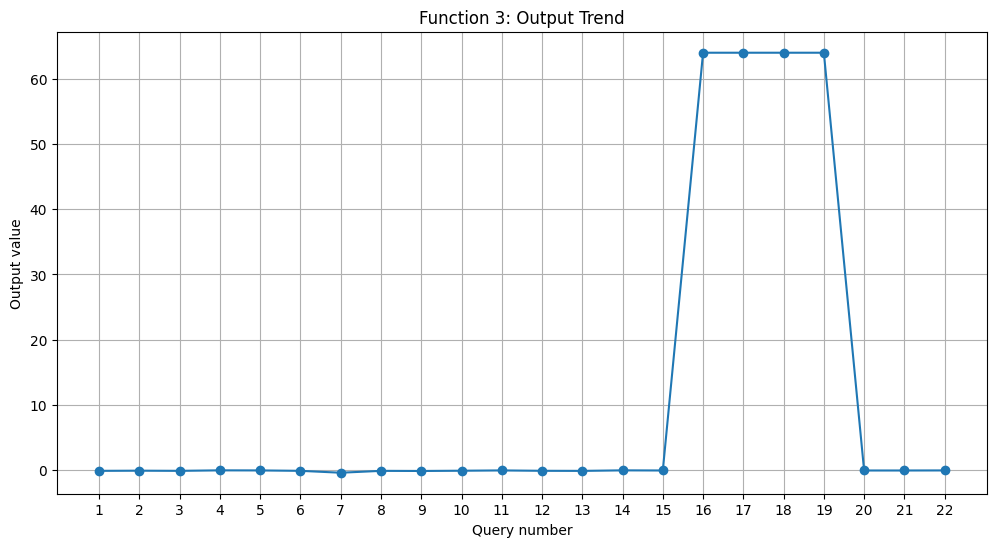

In [165]:
# ============================================================
# FUNCTION 3 — OUTPUT TREND
# ============================================================

query_numbers = np.arange(1, len(y3) + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    y3,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Output value")
plt.title("Function 3: Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

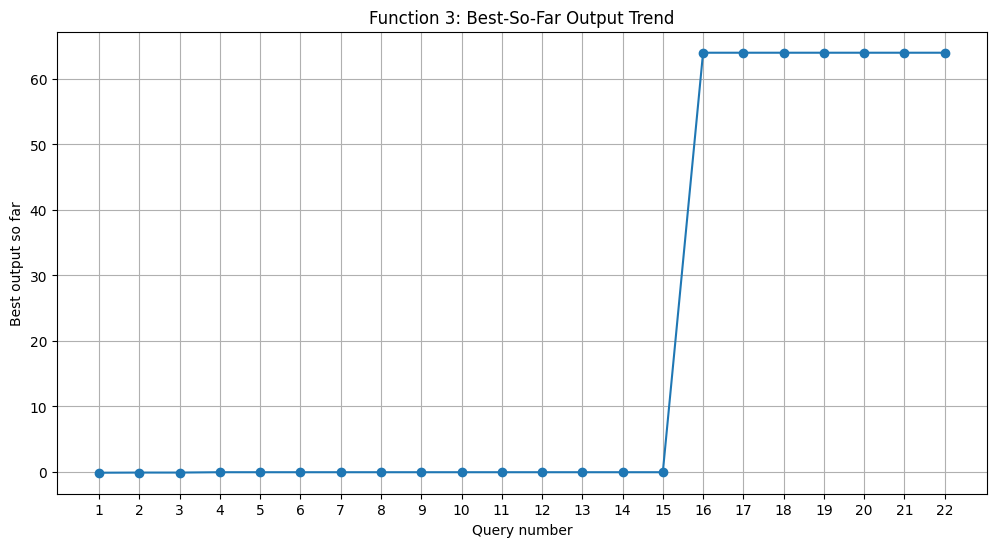

In [166]:
# ============================================================
# FUNCTION 3 — BEST-SO-FAR OUTPUT TREND
# ============================================================

best_so_far_3 = np.maximum.accumulate(y3)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    best_so_far_3,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Best output so far")
plt.title("Function 3: Best-So-Far Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

In [167]:
# ============================================================
# FUNCTION 3 — BEST QUERY POINT
# ============================================================

best_index_3 = np.argmax(y3)

best_query_number_3 = best_index_3 + 1
best_input_3 = X3[best_index_3]
best_output_3 = y3[best_index_3]

print("Best query number:", best_query_number_3)
print("Best input point:", best_input_3)
print("Best x1 value:", best_input_3[0])
print("Best x2 value:", best_input_3[1])
print("Best x3 value:", best_input_3[2])
print("Best output value:", best_output_3)

Best query number: 16
Best input point: [0.444444 0.666666 0.333333]
Best x1 value: 0.444444
Best x2 value: 0.666666
Best x3 value: 0.333333
Best output value: 64.0


In [168]:
function_3_df.sort_values("Output", ascending=False).head(10)

,Query_Number,x1,x2,x3,Output
17,18,0.444444,0.666666,0.333333,64.000000
18,19,0.444444,0.666666,0.333333,64.000000
15,16,0.444444,0.666666,0.333333,64.000000
16,17,0.444444,0.666666,0.333333,64.000000
3,4,0.492581,0.611593,0.340176,-0.034835
13,14,0.600097,0.725136,0.066089,-0.036378
10,11,0.220549,0.297825,0.343555,-0.046947
21,22,0.427731,0.669810,0.343678,-0.047183
4,5,0.134622,0.219917,0.458206,-0.048008
14,15,0.965995,0.861120,0.566829,-0.056758


              x1        x2        x3    Output
x1      1.000000  0.243985 -0.126538  0.038619
x2      0.243985  1.000000 -0.315236  0.306051
x3     -0.126538 -0.315236  1.000000 -0.122071
Output  0.038619  0.306051 -0.122071  1.000000


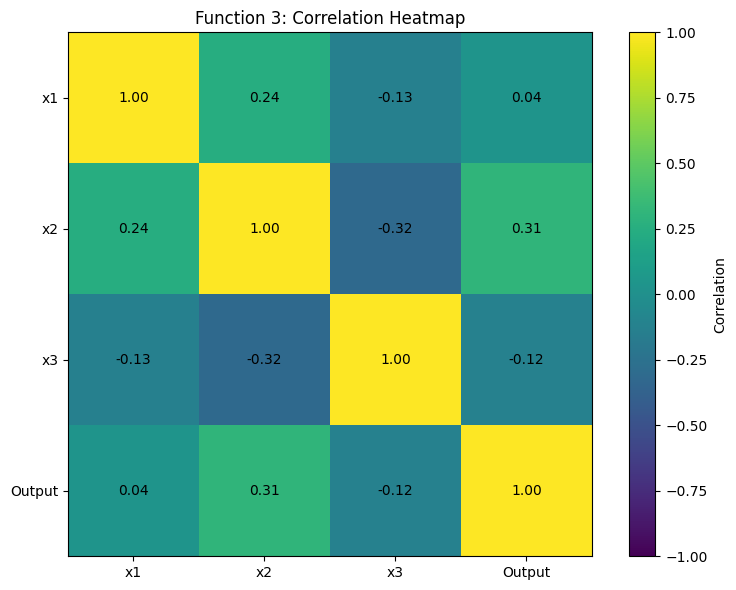

In [169]:
# ============================================================
# FUNCTION 3 — CORRELATION HEATMAP
# ============================================================

correlation_3 = function_3_df[
    ["x1", "x2", "x3", "Output"]
].corr()
print(correlation_3)
plt.figure(figsize=(8, 6))
plt.imshow(
    correlation_3,
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_3.columns)),
    correlation_3.columns
)
plt.yticks(
    range(len(correlation_3.columns)),
    correlation_3.columns
)
for i in range(len(correlation_3.columns)):
    for j in range(len(correlation_3.columns)):
        plt.text(
            j,
            i,
            f"{correlation_3.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Function 3: Correlation Heatmap")
plt.tight_layout()
plt.show()

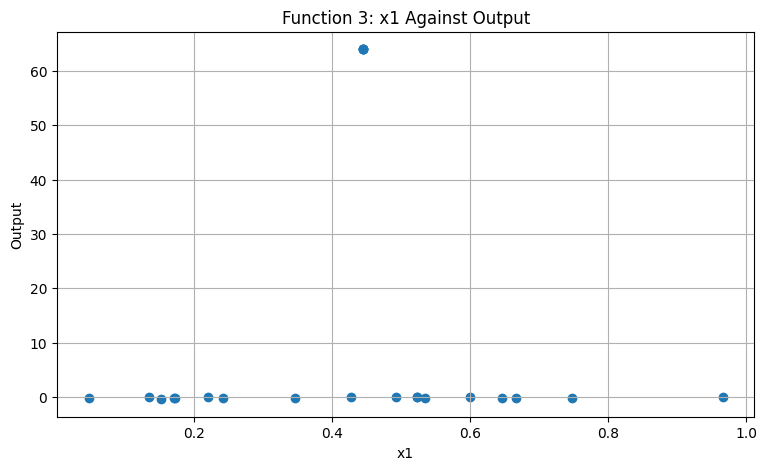

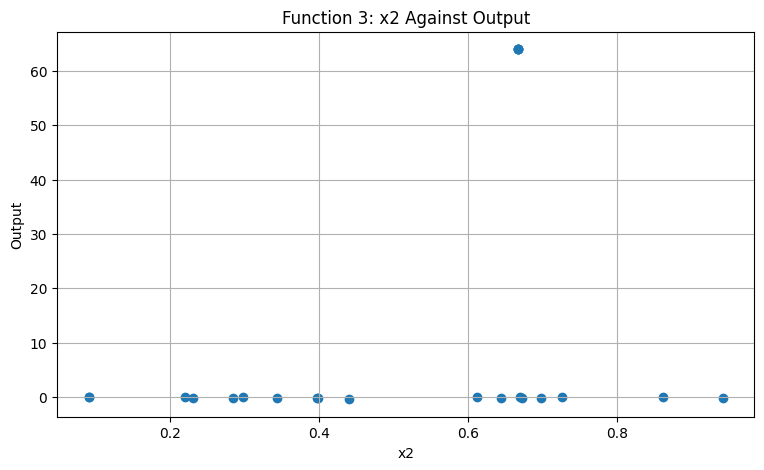

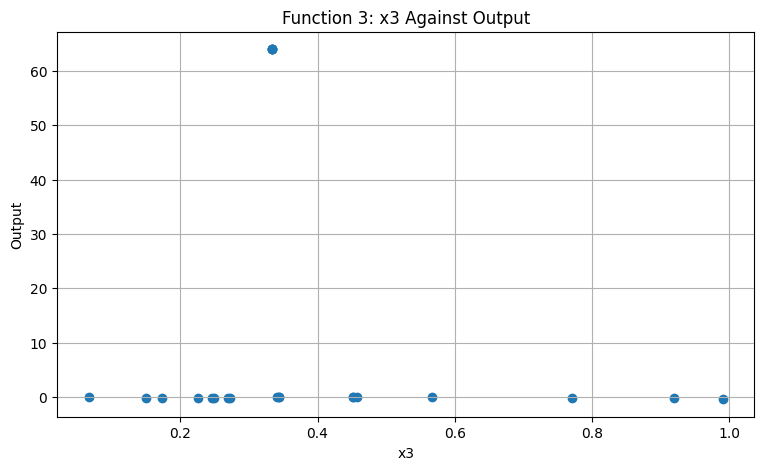

In [170]:
# ============================================================
# FUNCTION 3 — INPUT-OUTPUT SCATTER PLOTS
# ============================================================

# x1 against output
plt.figure(figsize=(9, 5))
plt.scatter(X3[:, 0], y3)
plt.xlabel("x1")
plt.ylabel("Output")
plt.title("Function 3: x1 Against Output")
plt.grid(True)
plt.show()

# x2 against output
plt.figure(figsize=(9, 5))
plt.scatter(X3[:, 1], y3)
plt.xlabel("x2")
plt.ylabel("Output")
plt.title("Function 3: x2 Against Output")
plt.grid(True)
plt.show()

# x3 against output
plt.figure(figsize=(9, 5))
plt.scatter(X3[:, 2], y3)
plt.xlabel("x3")
plt.ylabel("Output")
plt.title("Function 3: x3 Against Output")
plt.grid(True)
plt.show()

In [171]:
# ============================================================
# FUNCTION 3 — INITIALISE AND FIT GP
# ============================================================

length_scale_3 = np.array([0.05,0.05,0.05])

kernel_3 = RBF(
    length_scale=length_scale_3,
    length_scale_bounds="fixed"
)

gp_3 = GaussianProcessRegressor(
    kernel=kernel_3,
    alpha=1e-4,
    normalize_y=True
)

gp_3.fit(X3, y3)

print("Gaussian Process fitted successfully for Function 3.")
print("Kernel:", gp_3.kernel_)

Gaussian Process fitted successfully for Function 3.
Kernel: RBF(length_scale=[0.05, 0.05, 0.05])


In [172]:
# ============================================================
# FUNCTION 3 — GENERATE CANDIDATE POINTS
# ============================================================

np.random.seed(42)

num_candidates = 10000

candidate_X3 = np.random.uniform(
    low=0.0,
    high=1.0,
    size=(num_candidates, dim)
)

print("Candidate shape:", candidate_X3.shape)
print("\nFirst five candidate points:")
print(candidate_X3[:5])

Candidate shape: (10000, 3)

First five candidate points:
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497]]


In [173]:
# ============================================================
# FUNCTION 3 — UCB ACQUISITION FUNCTION
# ============================================================

kappa = 1.5

predicted_mean_3, predicted_std_3 = gp_3.predict(
    candidate_X3,
    return_std=True
)

ucb_3 = predicted_mean_3 + kappa * predicted_std_3

print("UCB calculated successfully for Function 3.")
print("Number of UCB scores:", len(ucb_3))

UCB calculated successfully for Function 3.
Number of UCB scores: 10000


In [174]:
# ============================================================
# FUNCTION 3 — SELECT NEXT QUERY POINT
# ============================================================

next_index_3 = np.argmax(ucb_3)

next_query_3 = candidate_X3[next_index_3]
next_mean_3 = predicted_mean_3[next_index_3]
next_std_3 = predicted_std_3[next_index_3]
next_ucb_3 = ucb_3[next_index_3]

print("FUNCTION 3 NEXT QUERY")
print("-" * 50)

print("Selected query point:")
print(next_query_3)

print("\nx1:", next_query_3[0])
print("x2:", next_query_3[1])
print("x3:", next_query_3[2])

print("\nGP predicted mean:", next_mean_3)
print("GP predicted uncertainty:", next_std_3)
print("UCB score:", next_ucb_3)

FUNCTION 3 NEXT QUERY
--------------------------------------------------
Selected query point:
[0.45734703 0.66402161 0.29599298]

x1: 0.45734702594910726
x2: 0.6640216067199792
x3: 0.29599298216572867

GP predicted mean: 112.97074327239878
GP predicted uncertainty: 13.947925481936132
UCB score: 133.89263149530296


In [175]:
# ============================================================
# FUNCTION 3 — SUBMISSION FORMAT
# ============================================================

print(
    f"Function 3 query: "
    f"[{next_query_3[0]:.6f}-{next_query_3[1]:.6f}-{next_query_3[2]:.6f}]"
)

Function 3 query: [0.457347-0.664022-0.295993]


***FUNCTION 4 FOR WEEK 8***

In [176]:
# ============================================================
# FUNCTION 4 — LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Week 8 dataset path
week_8_path = "/content/week_8_dataset"

# Function number and dimensions
f = 4
dim = 4

# Load Function 4 inputs
X4 = np.load(
    week_8_path + "/function_4_inputs.npy",
    allow_pickle=True
)

# Load Function 4 outputs
y4 = np.load(
    week_8_path + "/function_4_outputs.npy",
    allow_pickle=True
)

# Convert to clean numerical arrays
X4 = np.asarray(X4, dtype=float).reshape(-1, dim)
y4 = np.asarray(y4, dtype=float).reshape(-1)

print("Function 4 loaded successfully.")
print("X4 shape:", X4.shape)
print("y4 shape:", y4.shape)

Function 4 loaded successfully.
X4 shape: (37, 4)
y4 shape: (37,)


In [177]:
# ============================================================
# FUNCTION 4 — SHAPES AND MISSING VALUES
# ============================================================

print("Input shape:", X4.shape)
print("Output shape:", y4.shape)

print("\nNumber of input rows:", X4.shape[0])
print("Number of input variables:", X4.shape[1])
print("Number of output values:", len(y4))

print("\nMissing values in X4:", np.isnan(X4).sum())
print("Missing values in y4:", np.isnan(y4).sum())

print("\nInfinite values in X4:", np.isinf(X4).sum())
print("Infinite values in y4:", np.isinf(y4).sum())

if len(X4) == len(y4):
    print("\nCheck passed: every input point has a corresponding output.")
else:
    print("\nWarning: the numbers of inputs and outputs do not match.")

Input shape: (37, 4)
Output shape: (37,)

Number of input rows: 37
Number of input variables: 4
Number of output values: 37

Missing values in X4: 0
Missing values in y4: 0

Infinite values in X4: 0
Infinite values in y4: 0

Check passed: every input point has a corresponding output.


In [178]:
# ============================================================
# FUNCTION 4 — CREATE DATAFRAME
# ============================================================

function_4_df = pd.DataFrame({
    "Query_Number": np.arange(1, len(y4) + 1),
    "x1": X4[:, 0],
    "x2": X4[:, 1],
    "x3": X4[:, 2],
    "x4": X4[:, 3],
    "Output": y4
})

function_4_df

,Query_Number,x1,x2,x3,x4,Output
0,1,0.896981,0.725628,0.175404,0.701694,-22.108288
1,2,0.889356,0.499588,0.539269,0.508783,-14.601397
2,3,0.250946,0.033693,0.145380,0.494932,-11.699932
3,4,0.346962,0.006250,0.760564,0.613024,-16.053765
4,5,0.124871,0.129770,0.384400,0.287076,-10.069633
5,6,0.801303,0.500231,0.706645,0.195103,-15.487083
6,7,0.247708,0.060445,0.042186,0.441324,-12.681685
7,8,0.746702,0.757092,0.369353,0.206566,-16.026400
8,9,0.400665,0.072574,0.886768,0.243842,-17.049235
9,10,0.626071,0.586751,0.438806,0.778858,-12.741766


In [179]:
# ============================================================
# FUNCTION 4 — SUMMARY STATISTICS
# ============================================================

print("FUNCTION 4 SUMMARY STATISTICS")
print("-" * 50)

print(function_4_df[["x1", "x2", "x3", "x4", "Output"]].describe())

print("\nMinimum output:", np.min(y4))
print("Maximum output:", np.max(y4))
print("Mean output:", np.mean(y4))
print("Median output:", np.median(y4))
print("Output standard deviation:", np.std(y4))

FUNCTION 4 SUMMARY STATISTICS
--------------------------------------------------
              x1         x2         x3         x4     Output
count  37.000000  37.000000  37.000000  37.000000  37.000000
mean    0.541404   0.446409   0.403275   0.402199 -13.764907
std     0.277160   0.293129   0.272471   0.302861  15.391846
min     0.037825   0.006250   0.014095   0.068347 -32.625660
25%     0.282138   0.166086   0.206139   0.111111 -19.989498
50%     0.555555   0.472367   0.369353   0.287076 -16.026400
75%     0.738613   0.666933   0.687152   0.701694 -11.699932
max     0.985622   0.919592   0.939178   0.999483  64.000000

Minimum output: -32.625660215962455
Maximum output: 64.0
Mean output: -13.764907461263647
Median output: -16.02639976898352
Output standard deviation: 15.182423803861832


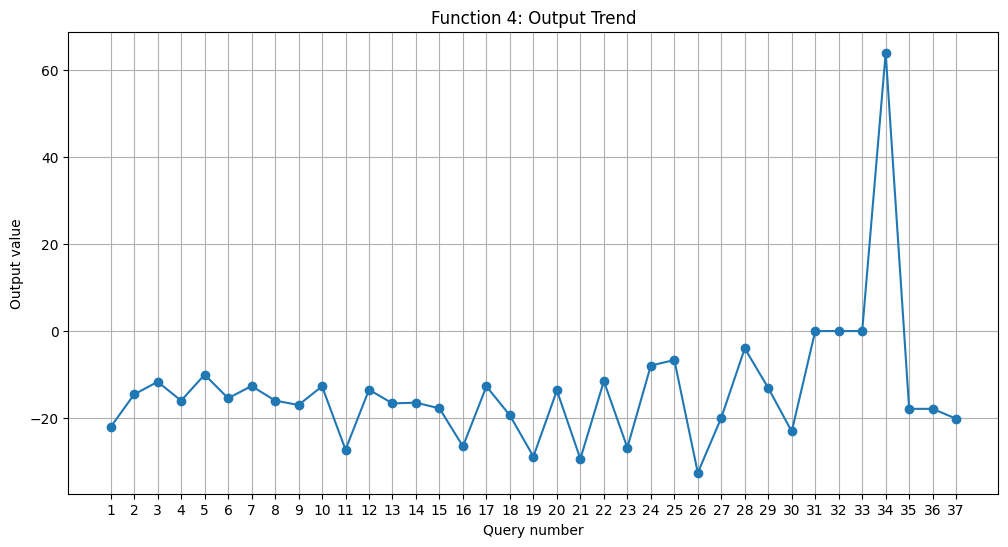

In [180]:
# ============================================================
# FUNCTION 4 — OUTPUT TREND
# ============================================================

query_numbers = np.arange(1, len(y4) + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    y4,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Output value")
plt.title("Function 4: Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

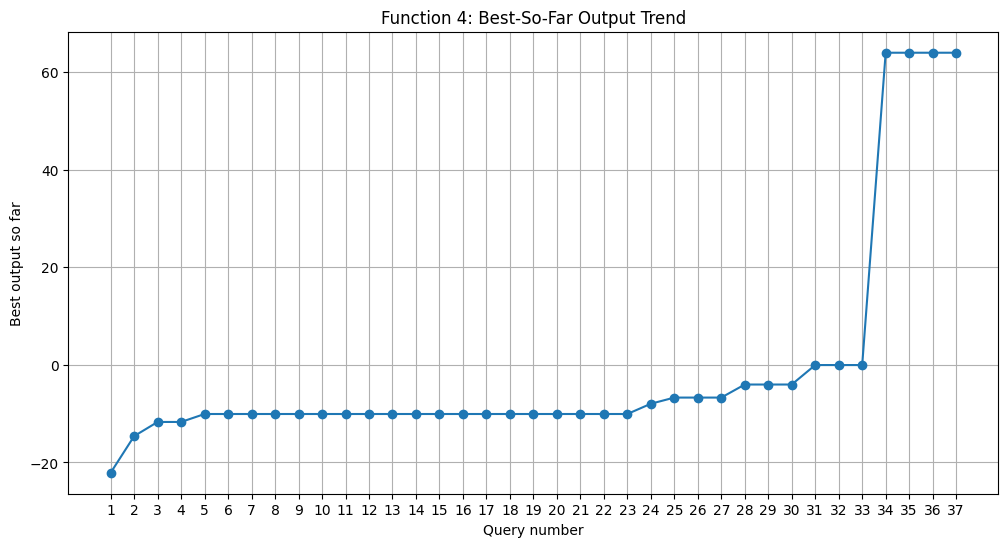

In [181]:
# ============================================================
# FUNCTION 4 — BEST-SO-FAR OUTPUT TREND
# ============================================================

best_so_far_4 = np.maximum.accumulate(y4)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    best_so_far_4,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Best output so far")
plt.title("Function 4: Best-So-Far Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

In [182]:
# ============================================================
# FUNCTION 4 — BEST QUERY POINT
# ============================================================

best_index_4 = np.argmax(y4)

best_query_number_4 = best_index_4 + 1
best_input_4 = X4[best_index_4]
best_output_4 = y4[best_index_4]

print("Best query number:", best_query_number_4)
print("Best input point:", best_input_4)
print("Best x1 value:", best_input_4[0])
print("Best x2 value:", best_input_4[1])
print("Best x3 value:", best_input_4[2])
print("Best x4 value:", best_input_4[3])
print("Best output value:", best_output_4)

Best query number: 34
Best input point: [0.555555 0.444444 0.222222 0.111111]
Best x1 value: 0.555555
Best x2 value: 0.444444
Best x3 value: 0.222222
Best x4 value: 0.111111
Best output value: 64.0


In [183]:
function_4_df.sort_values("Output", ascending=False).head(10)

,Query_Number,x1,x2,x3,x4,Output
33,34,0.555555,0.444444,0.222222,0.111111,64.000000
30,31,0.555555,0.444444,0.222222,0.111111,-0.031830
31,32,0.555555,0.444444,0.222222,0.111111,-0.031830
32,33,0.555555,0.444444,0.222222,0.111111,-0.031830
27,28,0.577766,0.428772,0.425826,0.249007,-4.025542
24,25,0.326076,0.472367,0.453192,0.105887,-6.702089
23,24,0.282138,0.505987,0.530531,0.096302,-7.966775
4,5,0.124871,0.129770,0.384400,0.287076,-10.069633
21,22,0.170347,0.756959,0.276520,0.531231,-11.565742
2,3,0.250946,0.033693,0.145380,0.494932,-11.699932


              x1        x2        x3        x4    Output
x1      1.000000  0.259416  0.213313  0.162305 -0.194674
x2      0.259416  1.000000  0.076133  0.269810 -0.182759
x3      0.213313  0.076133  1.000000  0.128674 -0.178948
x4      0.162305  0.269810  0.128674  1.000000 -0.413916
Output -0.194674 -0.182759 -0.178948 -0.413916  1.000000


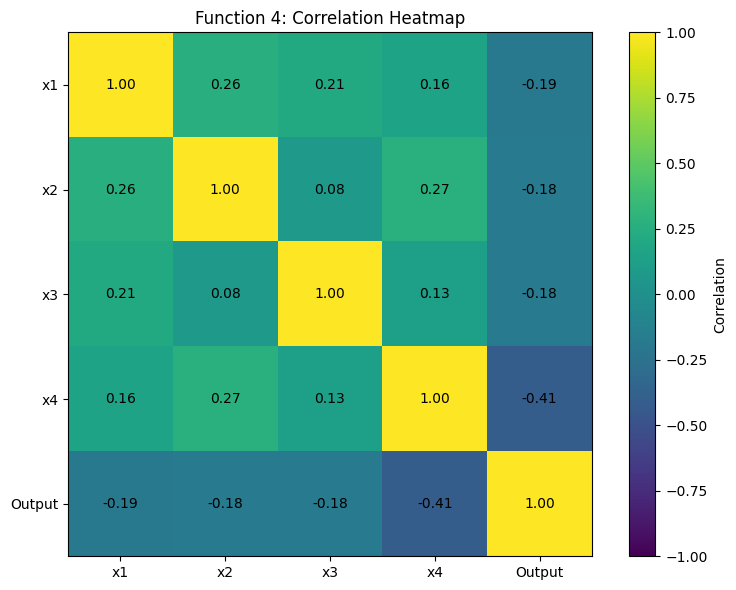

In [184]:
# ============================================================
# FUNCTION 4 — CORRELATION HEATMAP
# ============================================================

correlation_4 = function_4_df[
    ["x1", "x2", "x3", "x4", "Output"]
].corr()

print(correlation_4)

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_4,
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_4.columns)),
    correlation_4.columns
)

plt.yticks(
    range(len(correlation_4.columns)),
    correlation_4.columns
)

for i in range(len(correlation_4.columns)):
    for j in range(len(correlation_4.columns)):
        plt.text(
            j,
            i,
            f"{correlation_4.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Function 4: Correlation Heatmap")
plt.tight_layout()
plt.show()

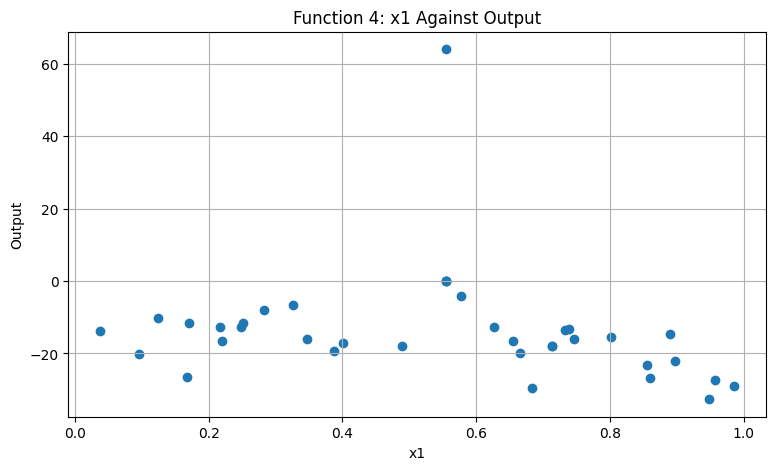

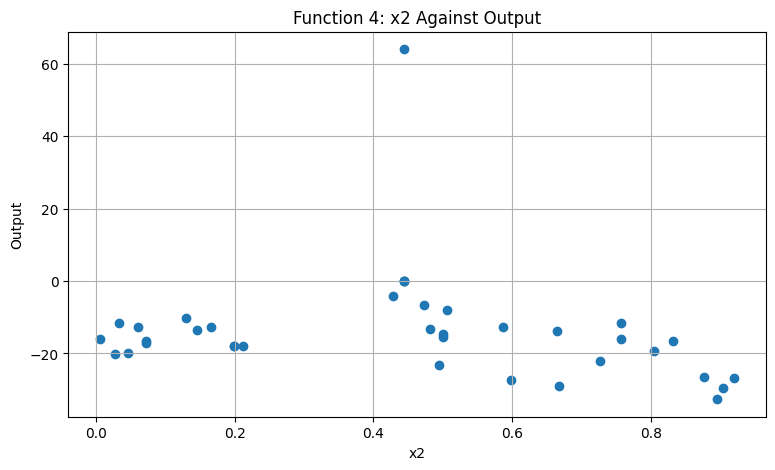

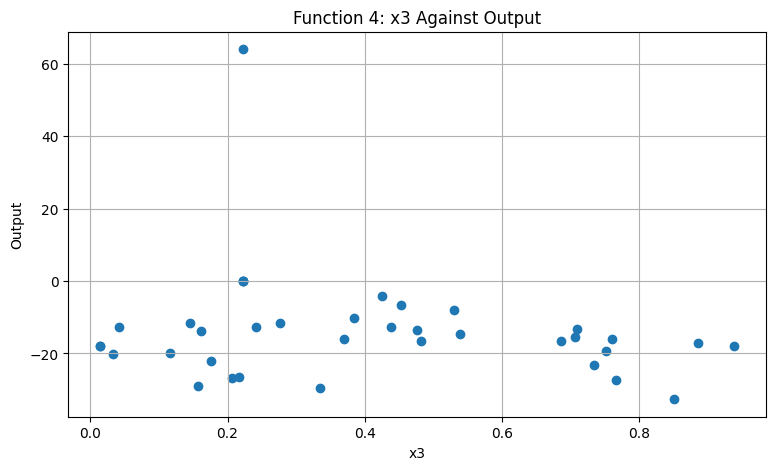

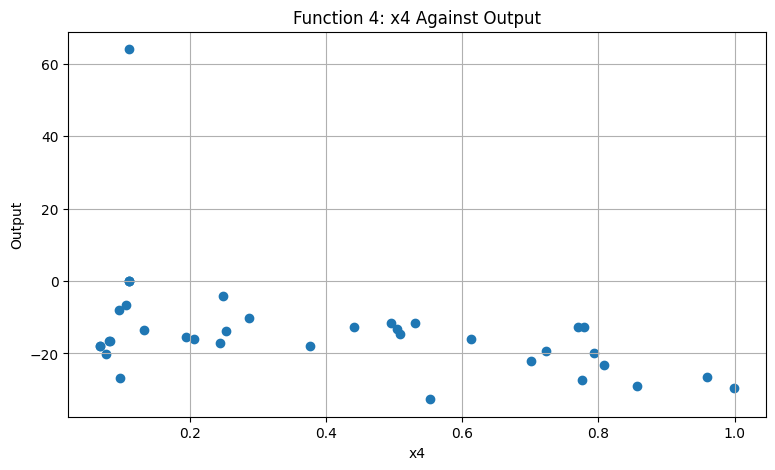

In [185]:
# ============================================================
# FUNCTION 4 — INPUT-OUTPUT SCATTER PLOTS
# ============================================================

# x1 against output
plt.figure(figsize=(9, 5))
plt.scatter(X4[:, 0], y4)
plt.xlabel("x1")
plt.ylabel("Output")
plt.title("Function 4: x1 Against Output")
plt.grid(True)
plt.show()

# x2 against output
plt.figure(figsize=(9, 5))
plt.scatter(X4[:, 1], y4)
plt.xlabel("x2")
plt.ylabel("Output")
plt.title("Function 4: x2 Against Output")
plt.grid(True)
plt.show()

# x3 against output
plt.figure(figsize=(9, 5))
plt.scatter(X4[:, 2], y4)
plt.xlabel("x3")
plt.ylabel("Output")
plt.title("Function 4: x3 Against Output")
plt.grid(True)
plt.show()

# x4 against output
plt.figure(figsize=(9, 5))
plt.scatter(X4[:, 3], y4)
plt.xlabel("x4")
plt.ylabel("Output")
plt.title("Function 4: x4 Against Output")
plt.grid(True)
plt.show()

In [186]:
# ============================================================
# FUNCTION 4 — INITIALISE AND FIT GP
# ============================================================

length_scale_4 = np.array([1,1,1,1])

kernel_4 = RBF(
    length_scale=length_scale_4,
    length_scale_bounds="fixed"
)

gp_4 = GaussianProcessRegressor(
    kernel=kernel_4,
    alpha=1e-6,
    normalize_y=True
)

gp_4.fit(X4, y4)

print("Gaussian Process fitted successfully for Function 4.")
print("Kernel:", gp_4.kernel_)

Gaussian Process fitted successfully for Function 4.
Kernel: RBF(length_scale=[1, 1, 1, 1])


In [187]:
# ============================================================
# FUNCTION 4 — GENERATE CANDIDATE POINTS
# ============================================================

np.random.seed(42)

num_candidates = 10000

candidate_X4 = np.random.uniform(
    low=0.0,
    high=1.0,
    size=(num_candidates, dim)
)

print("Candidate shape:", candidate_X4.shape)
print("\nFirst five candidate points:")
print(candidate_X4[:5])

Candidate shape: (10000, 4)

First five candidate points:
[[0.37454012 0.95071431 0.73199394 0.59865848]
 [0.15601864 0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497 0.18340451]
 [0.30424224 0.52475643 0.43194502 0.29122914]]


In [188]:
# ============================================================
# FUNCTION 4 — UCB ACQUISITION FUNCTION
# ============================================================

kappa = 4.0

predicted_mean_4, predicted_std_4 = gp_4.predict(
    candidate_X4,
    return_std=True
)

ucb_4 = predicted_mean_4 + kappa * predicted_std_4

print("UCB calculated successfully for Function 4.")
print("Number of UCB scores:", len(ucb_4))

UCB calculated successfully for Function 4.
Number of UCB scores: 10000


In [189]:
# ============================================================
# FUNCTION 4 — SELECT NEXT QUERY POINT
# ============================================================

next_index_4 = np.argmax(ucb_4)

next_query_4 = candidate_X4[next_index_4]
next_mean_4 = predicted_mean_4[next_index_4]
next_std_4 = predicted_std_4[next_index_4]
next_ucb_4 = ucb_4[next_index_4]

print("FUNCTION 4 NEXT QUERY")
print("-" * 50)

print("Selected query point:")
print(next_query_4)

print("\nx1:", next_query_4[0])
print("x2:", next_query_4[1])
print("x3:", next_query_4[2])
print("x4:", next_query_4[3])

print("\nGP predicted mean:", next_mean_4)
print("GP predicted uncertainty:", next_std_4)
print("UCB score:", next_ucb_4)

FUNCTION 4 NEXT QUERY
--------------------------------------------------
Selected query point:
[0.0460092  0.77827349 0.97951124 0.08848786]

x1: 0.0460091978297269
x2: 0.7782734939976157
x3: 0.9795112370928859
x4: 0.08848786353275317

GP predicted mean: 83.51591785301356
GP predicted uncertainty: 1.5416575359501392
UCB score: 89.68254799681412


In [190]:
# ============================================================
# FUNCTION 4 — SUBMISSION FORMAT
# ============================================================

print(
    f"Function 4 query: "
    f"[{next_query_4[0]:.6f}-{next_query_4[1]:.6f}-"
    f"{next_query_4[2]:.6f}-{next_query_4[3]:.6f}]"
)

Function 4 query: [0.046009-0.778273-0.979511-0.088488]


***FUNCTION 5 FOR WEEK 8***

In [191]:
# ============================================================
# FUNCTION 5 — LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# Week 8 dataset path
week_8_path = "/content/week_8_dataset"

# Function number and dimensions
f = 5
dim = 4

# Load Function 5 inputs
X5 = np.load(
    week_8_path + "/function_5_inputs.npy",
    allow_pickle=True
)

# Load Function 5 outputs
y5 = np.load(
    week_8_path + "/function_5_outputs.npy",
    allow_pickle=True
)

# Convert to clean numerical arrays
X5 = np.asarray(X5, dtype=float).reshape(-1, dim)
y5 = np.asarray(y5, dtype=float).reshape(-1)

print("Function 5 loaded successfully.")
print("X5 shape:", X5.shape)
print("y5 shape:", y5.shape)

Function 5 loaded successfully.
X5 shape: (27, 4)
y5 shape: (27,)


In [192]:
# ============================================================
# FUNCTION 5 — SHAPES AND MISSING VALUES
# ============================================================

print("Input shape:", X5.shape)
print("Output shape:", y5.shape)

print("\nNumber of input rows:", X5.shape[0])
print("Number of input variables:", X5.shape[1])
print("Number of output values:", len(y5))

print("\nMissing values in X5:", np.isnan(X5).sum())
print("Missing values in y5:", np.isnan(y5).sum())

print("\nInfinite values in X5:", np.isinf(X5).sum())
print("Infinite values in y5:", np.isinf(y5).sum())

if len(X5) == len(y5):
    print("\nCheck passed: every input point has a corresponding output.")
else:
    print("\nWarning: the numbers of inputs and outputs do not match.")

Input shape: (27, 4)
Output shape: (27,)

Number of input rows: 27
Number of input variables: 4
Number of output values: 27

Missing values in X5: 0
Missing values in y5: 0

Infinite values in X5: 0
Infinite values in y5: 0

Check passed: every input point has a corresponding output.


In [193]:
# ============================================================
# FUNCTION 5 — CREATE DATAFRAME
# ============================================================

function_5_df = pd.DataFrame({
    "Query_Number": np.arange(1, len(y5) + 1),
    "x1": X5[:, 0],
    "x2": X5[:, 1],
    "x3": X5[:, 2],
    "x4": X5[:, 3],
    "Output": y5
})

function_5_df

,Query_Number,x1,x2,x3,x4,Output
0,1,0.191447,0.038193,0.607418,0.414584,64.443440
1,2,0.758653,0.536518,0.656000,0.360342,18.301380
2,3,0.438350,0.804340,0.210245,0.151295,0.112940
3,4,0.706051,0.534192,0.264243,0.482088,4.210898
4,5,0.836478,0.193610,0.663893,0.785649,258.370525
5,6,0.683432,0.118663,0.829046,0.567577,78.434389
6,7,0.553621,0.667350,0.323806,0.814870,57.571537
7,8,0.352356,0.322242,0.116979,0.473113,109.571876
8,9,0.153786,0.729382,0.422598,0.443074,8.847992
9,10,0.463442,0.630025,0.107906,0.957644,233.223610


In [194]:
# ============================================================
# FUNCTION 5 — SUMMARY STATISTICS
# ============================================================

print("FUNCTION 5 SUMMARY STATISTICS")
print("-" * 50)

print(function_5_df[["x1", "x2", "x3", "x4", "Output"]].describe())

print("\nMinimum output:", np.min(y5))
print("Maximum output:", np.max(y5))
print("Mean output:", np.mean(y5))
print("Median output:", np.median(y5))
print("Output standard deviation:", np.std(y5))

FUNCTION 5 SUMMARY STATISTICS
--------------------------------------------------
              x1         x2         x3         x4       Output
count  27.000000  27.000000  27.000000  27.000000    27.000000
mean    0.430138   0.532081   0.516400   0.519353   127.645935
std     0.245292   0.285884   0.276986   0.322000   220.740492
min     0.000000   0.000000   0.000000   0.000000     0.112940
25%     0.224189   0.319560   0.335952   0.248779    21.362234
50%     0.438350   0.536518   0.479592   0.473113    64.000000
75%     0.680462   0.811148   0.749436   0.864159    94.650503
max     0.836478   0.862540   0.879484   0.957644  1088.859618

Minimum output: 0.1129397953712203
Maximum output: 1088.8596181962705
Mean output: 127.64593502542874
Median output: 64.0
Output standard deviation: 216.6141375127323


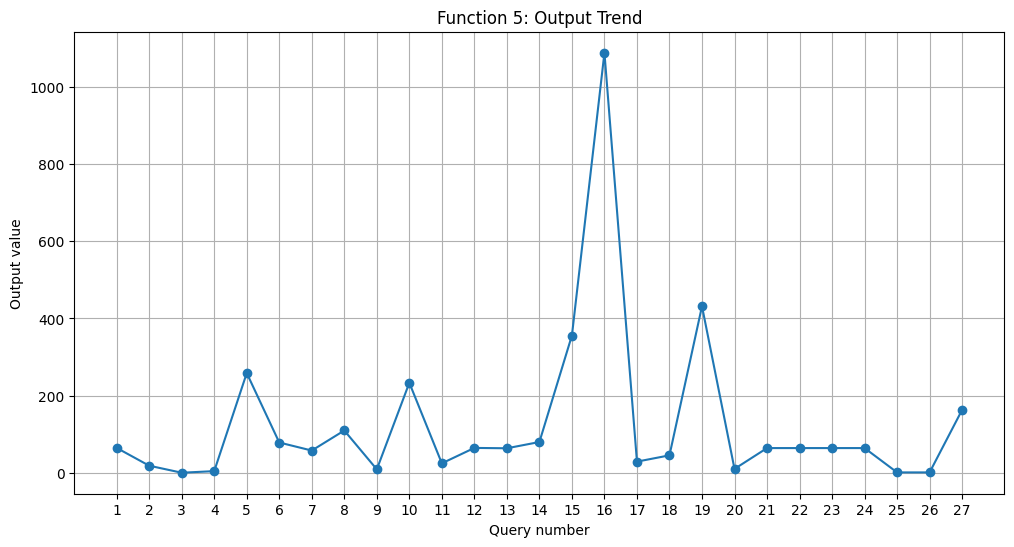

In [195]:
# ============================================================
# FUNCTION 5 — OUTPUT TREND
# ============================================================

query_numbers = np.arange(1, len(y5) + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    y5,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Output value")
plt.title("Function 5: Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

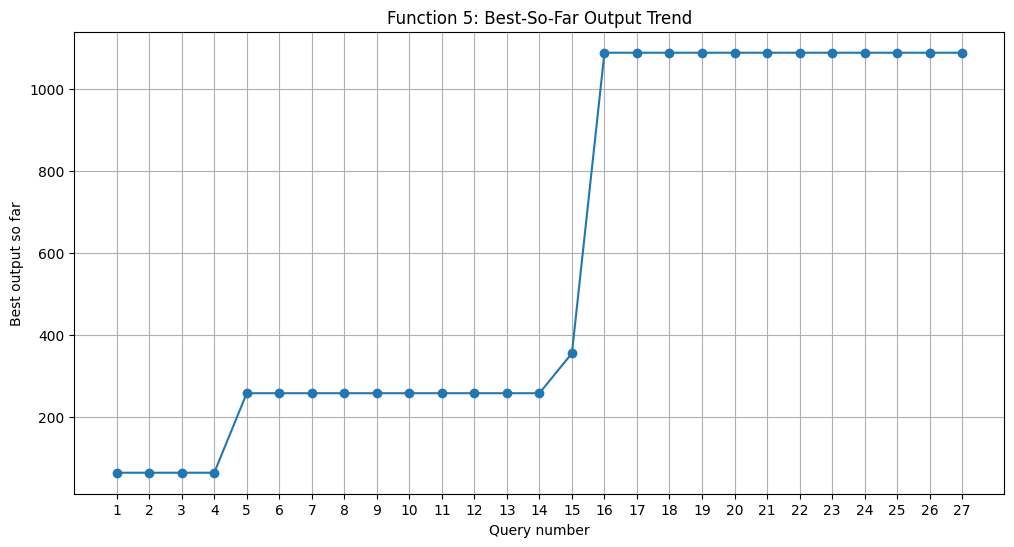

In [196]:
# ============================================================
# FUNCTION 5 — BEST-SO-FAR OUTPUT TREND
# ============================================================

best_so_far_5 = np.maximum.accumulate(y5)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers,
    best_so_far_5,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Best output so far")
plt.title("Function 5: Best-So-Far Output Trend")
plt.xticks(query_numbers)
plt.grid(True)
plt.show()

In [197]:
# ============================================================
# FUNCTION 5 — BEST QUERY POINT
# ============================================================

best_index_5 = np.argmax(y5)

best_query_number_5 = best_index_5 + 1
best_input_5 = X5[best_index_5]
best_output_5 = y5[best_index_5]

print("Best query number:", best_query_number_5)
print("Best input point:", best_input_5)
print("Best x1 value:", best_input_5[0])
print("Best x2 value:", best_input_5[1])
print("Best x3 value:", best_input_5[2])
print("Best x4 value:", best_input_5[3])
print("Best output value:", best_output_5)

Best query number: 16
Best input point: [0.22418902 0.84648049 0.87948418 0.87851568]
Best x1 value: 0.22418902330288348
Best x2 value: 0.8464804904862864
Best x3 value: 0.8794841797090803
Best x4 value: 0.8785156842249731
Best output value: 1088.8596181962705


In [198]:
function_5_df.sort_values("Output", ascending=False).head(10)

,Query_Number,x1,x2,x3,x4,Output
15,16,0.224189,0.846480,0.879484,0.878516,1088.859618
18,19,0.119879,0.862540,0.643331,0.849804,431.612757
14,15,0.438933,0.774092,0.378167,0.933696,355.806818
4,5,0.836478,0.193610,0.663893,0.785649,258.370525
9,10,0.463442,0.630025,0.107906,0.957644,233.223610
26,27,0.000000,0.000000,0.000000,0.000000,163.122500
7,8,0.352356,0.322242,0.116979,0.473113,109.571876
13,14,0.511142,0.817957,0.728710,0.112354,79.729130
5,6,0.683432,0.118663,0.829046,0.567577,78.434389
0,1,0.191447,0.038193,0.607418,0.414584,64.443440


              x1        x2        x3        x4    Output
x1      1.000000 -0.171413 -0.205115 -0.064416 -0.241546
x2     -0.171413  1.000000  0.279316  0.475025  0.245127
x3     -0.205115  0.279316  1.000000  0.270782  0.205175
x4     -0.064416  0.475025  0.270782  1.000000  0.418715
Output -0.241546  0.245127  0.205175  0.418715  1.000000


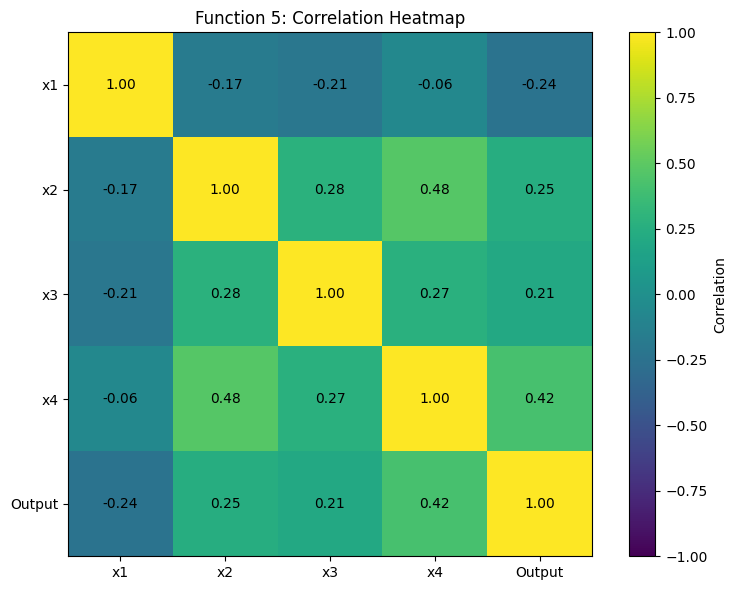

In [199]:
# ============================================================
# FUNCTION 5 — CORRELATION HEATMAP
# ============================================================

correlation_5 = function_5_df[
    ["x1", "x2", "x3", "x4", "Output"]
].corr()

print(correlation_5)

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_5,
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_5.columns)),
    correlation_5.columns
)

plt.yticks(
    range(len(correlation_5.columns)),
    correlation_5.columns
)

for i in range(len(correlation_5.columns)):
    for j in range(len(correlation_5.columns)):
        plt.text(
            j,
            i,
            f"{correlation_5.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Function 5: Correlation Heatmap")
plt.tight_layout()
plt.show()

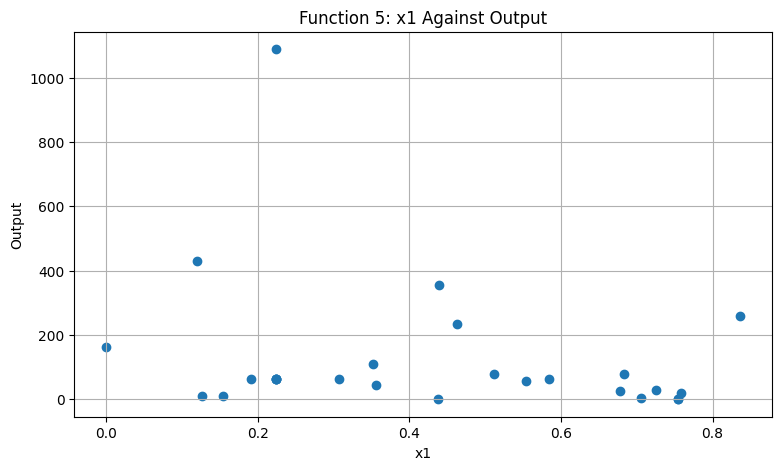

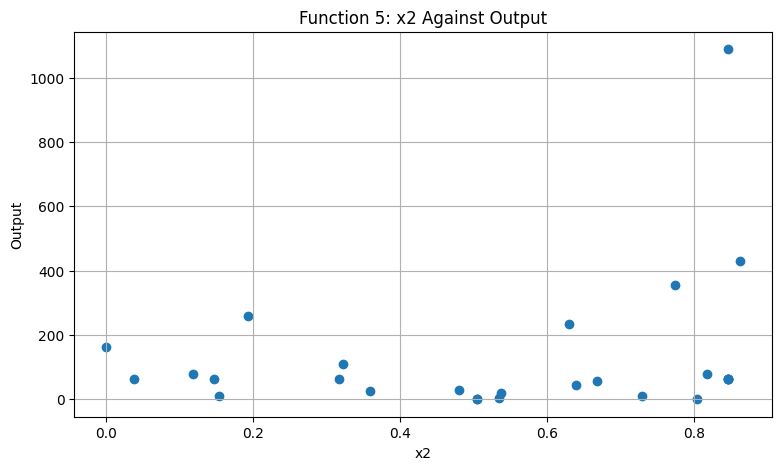

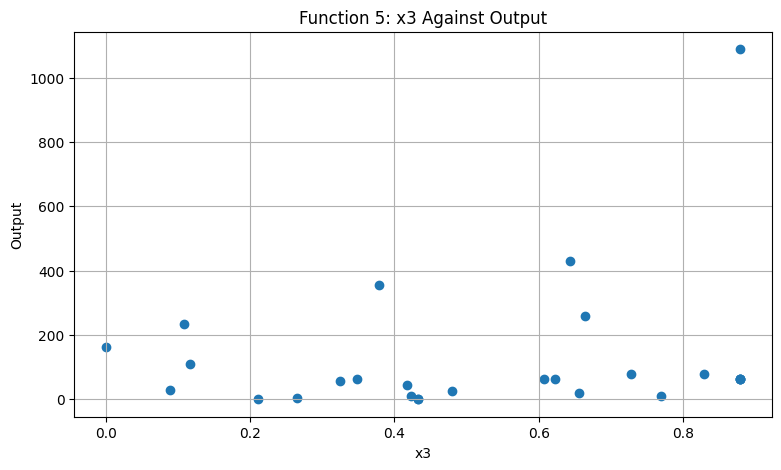

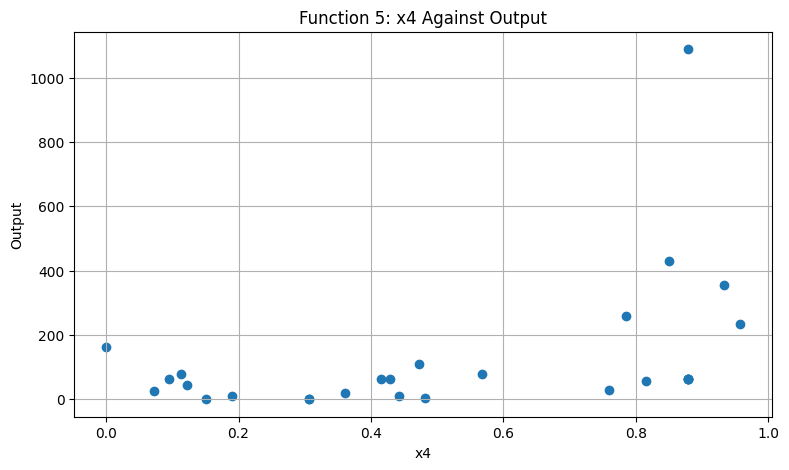

In [200]:
# ============================================================
# FUNCTION 5 — INPUT-OUTPUT SCATTER PLOTS
# ============================================================

plt.figure(figsize=(9, 5))
plt.scatter(X5[:, 0], y5)
plt.xlabel("x1")
plt.ylabel("Output")
plt.title("Function 5: x1 Against Output")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(X5[:, 1], y5)
plt.xlabel("x2")
plt.ylabel("Output")
plt.title("Function 5: x2 Against Output")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(X5[:, 2], y5)
plt.xlabel("x3")
plt.ylabel("Output")
plt.title("Function 5: x3 Against Output")
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(X5[:, 3], y5)
plt.xlabel("x4")
plt.ylabel("Output")
plt.title("Function 5: x4 Against Output")
plt.grid(True)
plt.show()

In [201]:
# ============================================================
# FUNCTION 5 — INITIALISE AND FIT GP
# ============================================================

length_scale_5 = np.array([1,1,1,1,])

kernel_5 = RBF(
    length_scale=length_scale_5,
    length_scale_bounds="fixed"
)

gp_5 = GaussianProcessRegressor(
    kernel=kernel_5,
    alpha=1e-4,
    normalize_y=True
)

gp_5.fit(X5, y5)

print("Gaussian Process fitted successfully for Function 5.")
print("Kernel:", gp_5.kernel_)

Gaussian Process fitted successfully for Function 5.
Kernel: RBF(length_scale=[1, 1, 1, 1])


In [202]:
# ============================================================
# FUNCTION 5 — GENERATE CANDIDATE POINTS
# ============================================================

np.random.seed(42)

num_candidates = 10000

candidate_X5 = np.random.uniform(
    low=0.0,
    high=1.0,
    size=(num_candidates, dim)
)

print("Candidate shape:", candidate_X5.shape)
print("\nFirst five candidate points:")
print(candidate_X5[:5])

Candidate shape: (10000, 4)

First five candidate points:
[[0.37454012 0.95071431 0.73199394 0.59865848]
 [0.15601864 0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497 0.18340451]
 [0.30424224 0.52475643 0.43194502 0.29122914]]


In [203]:
# ============================================================
# FUNCTION 5 — UCB ACQUISITION FUNCTION
# ============================================================

kappa = 2.5

predicted_mean_5, predicted_std_5 = gp_5.predict(
    candidate_X5,
    return_std=True
)

ucb_5 = predicted_mean_5 + kappa * predicted_std_5

print("UCB calculated successfully for Function 5.")
print("Number of UCB scores:", len(ucb_5))

UCB calculated successfully for Function 5.
Number of UCB scores: 10000


In [204]:
# ============================================================
# FUNCTION 5 — SELECT NEXT QUERY POINT
# ============================================================

next_index_5 = np.argmax(ucb_5)

next_query_5 = candidate_X5[next_index_5]
next_mean_5 = predicted_mean_5[next_index_5]
next_std_5 = predicted_std_5[next_index_5]
next_ucb_5 = ucb_5[next_index_5]

print("FUNCTION 5 NEXT QUERY")
print("-" * 50)

print("Selected query point:")
print(next_query_5)

print("\nx1:", next_query_5[0])
print("x2:", next_query_5[1])
print("x3:", next_query_5[2])
print("x4:", next_query_5[3])

print("\nGP predicted mean:", next_mean_5)
print("GP predicted uncertainty:", next_std_5)
print("UCB score:", next_ucb_5)

FUNCTION 5 NEXT QUERY
--------------------------------------------------
Selected query point:
[0.08122963 0.9925818  0.15620151 0.98842099]

x1: 0.08122963480667267
x2: 0.9925817954877634
x3: 0.15620150793059928
x4: 0.988420993963481

GP predicted mean: 1009.8935487846211
GP predicted uncertainty: 29.764876675234873
UCB score: 1084.3057404727083


In [205]:
# ============================================================
# FUNCTION 5 — SUBMISSION FORMAT
# ============================================================

print(
    f"Function 5 query: "
    f"[{next_query_5[0]:.6f}-{next_query_5[1]:.6f}-"
    f"{next_query_5[2]:.6f}-{next_query_5[3]:.6f}]"
)

Function 5 query: [0.081230-0.992582-0.156202-0.988421]


***FUNCTION 6 FOR WEEK 8***




In [206]:
# ============================================================
# FUNCTION 6 — LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

week_8_path = "/content/week_8_dataset"

f = 6
dim = 5

X6 = np.load(
    week_8_path + "/function_6_inputs.npy",
    allow_pickle=True
)

y6 = np.load(
    week_8_path + "/function_6_outputs.npy",
    allow_pickle=True
)

X6 = np.asarray(X6, dtype=float).reshape(-1, dim)
y6 = np.asarray(y6, dtype=float).reshape(-1)

print("Function 6 loaded successfully.")
print("X6 shape:", X6.shape)
print("y6 shape:", y6.shape)

Function 6 loaded successfully.
X6 shape: (27, 5)
y6 shape: (27,)


In [207]:
# ============================================================
# FUNCTION 6 — CHECK SHAPES AND MISSING VALUES
# ============================================================

print("Input shape:", X6.shape)
print("Output shape:", y6.shape)

print("\nNumber of input rows:", X6.shape[0])
print("Number of input variables:", X6.shape[1])
print("Number of output values:", len(y6))

print("\nMissing values in X6:", np.isnan(X6).sum())
print("Missing values in y6:", np.isnan(y6).sum())

print("\nInfinite values in X6:", np.isinf(X6).sum())
print("Infinite values in y6:", np.isinf(y6).sum())

if len(X6) == len(y6):
    print("\n✓ Every input has one output.")
else:
    print("\n⚠ Input and output sizes do not match.")

Input shape: (27, 5)
Output shape: (27,)

Number of input rows: 27
Number of input variables: 5
Number of output values: 27

Missing values in X6: 0
Missing values in y6: 0

Infinite values in X6: 0
Infinite values in y6: 0

✓ Every input has one output.


In [208]:
# ============================================================
# FUNCTION 6 — CREATE DATAFRAME
# ============================================================

function_6_df = pd.DataFrame({

    "Query_Number": np.arange(1, len(y6)+1),

    "x1": X6[:,0],
    "x2": X6[:,1],
    "x3": X6[:,2],
    "x4": X6[:,3],
    "x5": X6[:,4],

    "Output": y6

})

function_6_df

,Query_Number,x1,x2,x3,x4,x5,Output
0,1,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,2,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,3,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,4,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,5,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,6,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,7,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,8,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,9,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,10,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


In [209]:
# ============================================================
# FUNCTION 6 — SUMMARY STATISTICS
# ============================================================

print(function_6_df.describe())

print("\nMinimum Output:",np.min(y6))
print("Maximum Output:",np.max(y6))
print("Mean Output:",np.mean(y6))
print("Median Output:",np.median(y6))
print("Standard Deviation:",np.std(y6))

       Query_Number         x1         x2         x3         x4         x5  \
count     27.000000  27.000000  27.000000  27.000000  27.000000  27.000000   
mean      14.000000   0.600014   0.442625   0.554601   0.529214   0.487237   
std        7.937254   0.275432   0.320232   0.313060   0.285655   0.286848   
min        1.000000   0.021735   0.022732   0.016523   0.041715   0.004911   
25%        7.500000   0.435755   0.154693   0.376849   0.301579   0.254911   
50%       14.000000   0.728186   0.331802   0.679775   0.679021   0.564013   
75%       20.500000   0.776750   0.770892   0.755218   0.699498   0.650182   
max       27.000000   0.957740   0.931871   0.978806   0.961656   0.897560   

          Output  
count  27.000000  
mean    1.023098  
std    12.604870  
min    -2.571170  
25%    -1.724720  
50%    -1.309116  
75%    -1.040271  
max    64.000000  

Minimum Output: -2.5711696316081234
Maximum Output: 64.0
Mean Output: 1.0230981674609172
Median Output: -1.309116352823696
St

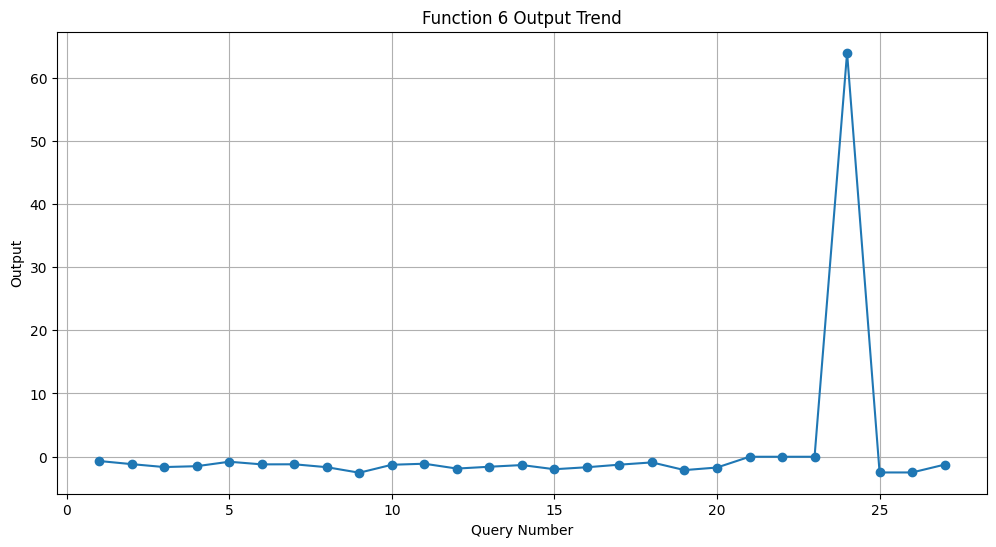

In [210]:
# ============================================================
# FUNCTION 6 — OUTPUT TREND
# ============================================================

query_numbers=np.arange(1,len(y6)+1)

plt.figure(figsize=(12,6))

plt.plot(query_numbers,y6,marker='o')

plt.xlabel("Query Number")
plt.ylabel("Output")

plt.title("Function 6 Output Trend")

plt.grid(True)

plt.show()

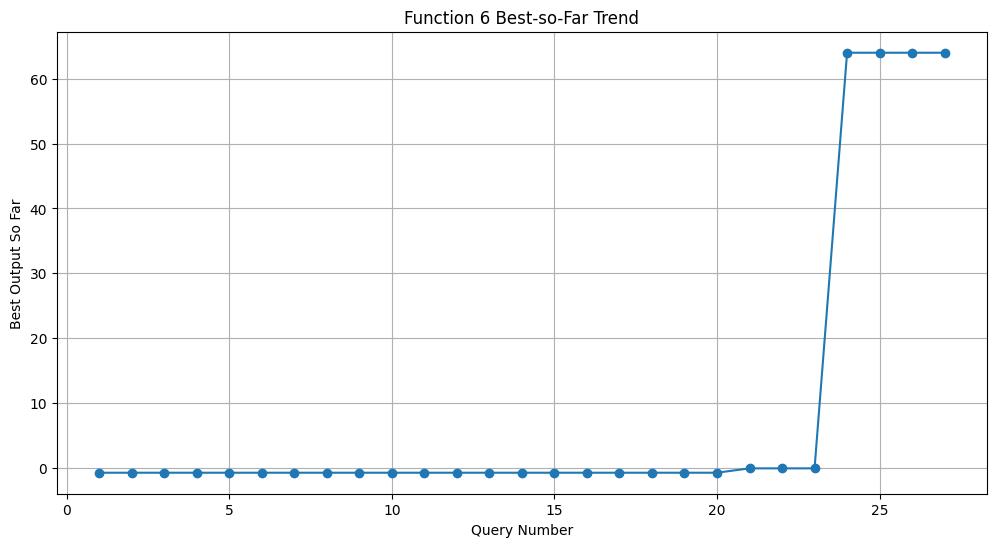

In [85]:
# ============================================================
# FUNCTION 6 — BEST SO FAR
# ============================================================

best_so_far=np.maximum.accumulate(y6)

plt.figure(figsize=(12,6))

plt.plot(query_numbers,best_so_far,marker='o')

plt.xlabel("Query Number")
plt.ylabel("Best Output So Far")

plt.title("Function 6 Best-so-Far Trend")

plt.grid(True)

plt.show()

In [86]:
# ============================================================
# FUNCTION 6 — BEST QUERY
# ============================================================

best_index=np.argmax(y6)
print("Best Query:",best_index+1)
print("\nBest Input")
print(X6[best_index])
print("\nBest Output")
print(y6[best_index])

Best Query: 24

Best Input
[0.728186 0.154693 0.732552 0.693997 0.564013]

Best Output
64.0


In [87]:
function_6_df.sort_values("Output", ascending=False).head(10)

,Query_Number,x1,x2,x3,x4,x5,Output
23,24,0.728186,0.154693,0.732552,0.693997,0.564013,64.000000
21,22,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
20,21,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
22,23,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
0,1,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
4,5,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
17,18,0.782880,0.536336,0.443284,0.859700,0.010326,-0.935757
10,11,0.536797,0.308781,0.411879,0.388225,0.522528,-1.144785
1,2,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
6,7,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786


              Query_Number        x1        x2        x3        x4        x5  \
Query_Number      1.000000  0.156658 -0.431310  0.274547 -0.171388  0.504178   
x1                0.156658  1.000000 -0.419674  0.132630  0.076944 -0.222629   
x2               -0.431310 -0.419674  1.000000 -0.118541 -0.029962 -0.124632   
x3                0.274547  0.132630 -0.118541  1.000000  0.031668  0.141064   
x4               -0.171388  0.076944 -0.029962  0.031668  1.000000 -0.307363   
x5                0.504178 -0.222629 -0.124632  0.141064 -0.307363  1.000000   
Output            0.250102  0.097055 -0.192013  0.120386  0.148051  0.032182   

                Output  
Query_Number  0.250102  
x1            0.097055  
x2           -0.192013  
x3            0.120386  
x4            0.148051  
x5            0.032182  
Output        1.000000  


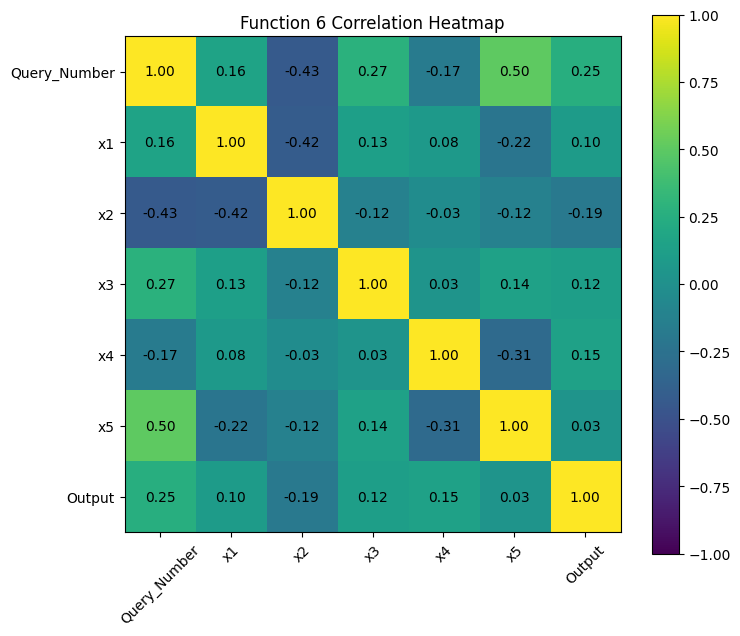

In [88]:
# ============================================================
# FUNCTION 6 — CORRELATION
# ============================================================

corr=function_6_df.corr()
print(corr)
plt.figure(figsize=(8,7))
plt.imshow(corr,vmin=-1,vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j,i,f"{corr.iloc[i,j]:.2f}",
                 ha="center",va="center")

plt.title("Function 6 Correlation Heatmap")

plt.show()

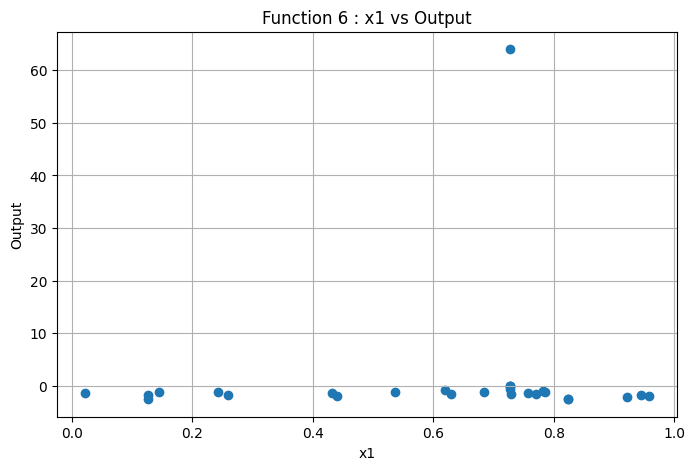

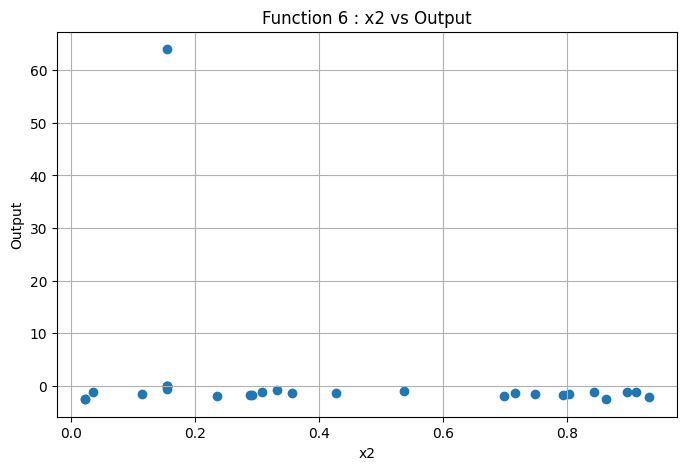

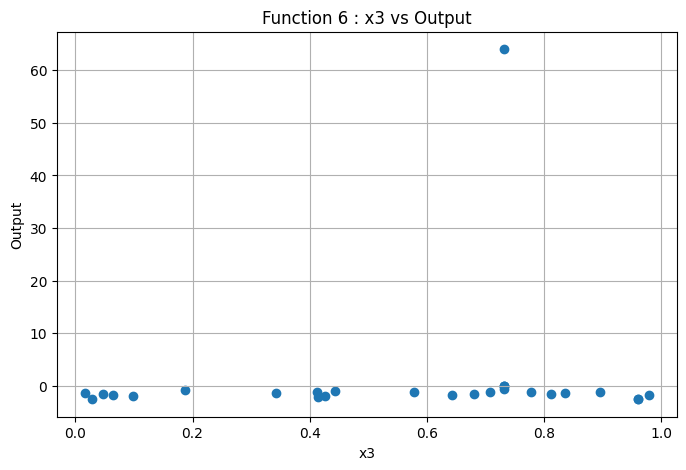

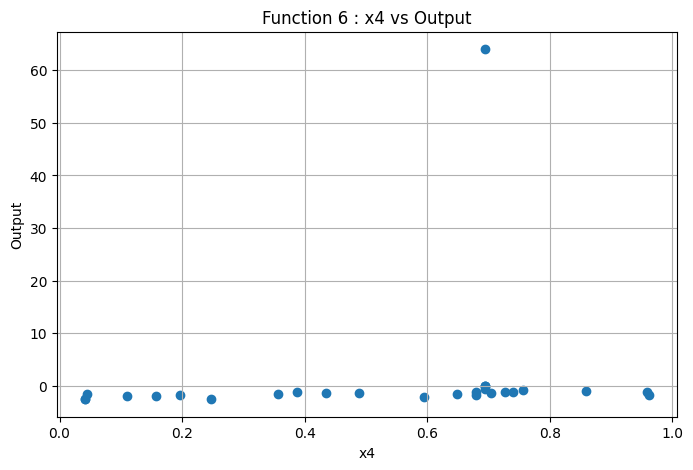

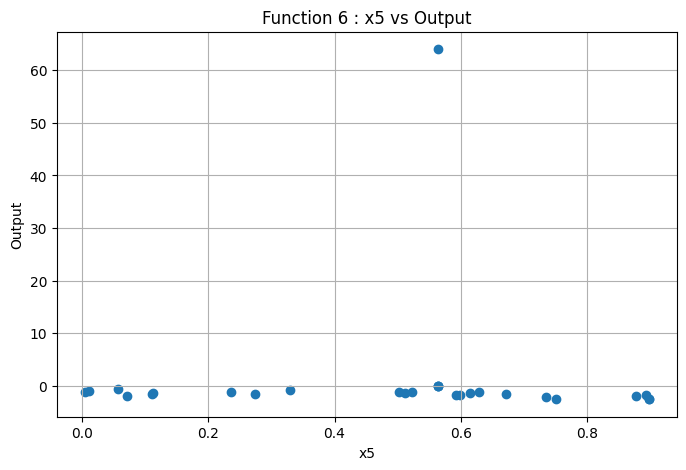

In [89]:
# ============================================================
# FUNCTION 6 — SCATTER PLOTS
# ============================================================

for i in range(dim):
    plt.figure(figsize=(8,5))
    plt.scatter(X6[:,i],y6)
    plt.xlabel(f"x{i+1}")
    plt.ylabel("Output")
    plt.title(f"Function 6 : x{i+1} vs Output")
    plt.grid(True)
    plt.show()

In [90]:
# ============================================================
# FUNCTION 6 — GP SURROGATE
# ============================================================

kernel=RBF(
    length_scale=np.array([1,1,1,1,1]),
    length_scale_bounds="fixed"
)

gp6=GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-4,
    normalize_y=True
)

gp6.fit(X6,y6)
print("GP fitted successfully.")
print(gp6.kernel_)

GP fitted successfully.
RBF(length_scale=[1, 1, 1, 1, 1])


In [91]:
# ============================================================
# FUNCTION 6 — GENERATE CANDIDATES
# ============================================================

np.random.seed(42)
num_candidates=10000
candidate_X6=np.random.uniform(
    0,
    1,
    size=(num_candidates,dim)
)
print(candidate_X6.shape)

(10000, 5)


In [92]:
# ============================================================
# FUNCTION 6 — UCB
# ============================================================

kappa=1.5
pred_mean,pred_std=gp6.predict(
    candidate_X6,
    return_std=True
)
ucb=pred_mean+kappa*pred_std
print("UCB completed.")

UCB completed.


In [93]:
# ============================================================
# FUNCTION 6 — NEXT QUERY
# ============================================================

best=np.argmax(ucb)
next_query=candidate_X6[best]
print("Recommended Query Point")
print(next_query)
print("\nPredicted Mean")
print(pred_mean[best])
print("\nPredicted Std")
print(pred_std[best])
print("\nUCB Score")
print(ucb[best])

Recommended Query Point
[0.99499263 0.31681887 0.50880075 0.55770584 0.57940283]

Predicted Mean
43.39153298275274

Predicted Std
1.38380618920929

UCB Score
45.46724226656668


In [94]:
# ============================================================
# FUNCTION 6 — SUBMISSION FORMAT
# ============================================================

print(
f"Function 6 Query = [{next_query[0]:.6f}-"
f"{next_query[1]:.6f}-"
f"{next_query[2]:.6f}-"
f"{next_query[3]:.6f}-"
f"{next_query[4]:.6f}]"
)

Function 6 Query = [0.994993-0.316819-0.508801-0.557706-0.579403]


***FUNCTION 7 FOR WEEK 8***

In [95]:
# ============================================================
# FUNCTION 7 — LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

week_8_path = "/content/week_8_dataset"

f = 7
dim = 6

X7 = np.load(
    week_8_path + "/function_7_inputs.npy",
    allow_pickle=True
)

y7 = np.load(
    week_8_path + "/function_7_outputs.npy",
    allow_pickle=True
)

X7 = np.asarray(X7, dtype=float).reshape(-1, dim)
y7 = np.asarray(y7, dtype=float).reshape(-1)

print("Function 7 loaded successfully.")
print("X7 shape:", X7.shape)
print("y7 shape:", y7.shape)

Function 7 loaded successfully.
X7 shape: (37, 6)
y7 shape: (37,)


In [96]:
# ============================================================
# FUNCTION 7 — CHECK SHAPES AND MISSING VALUES
# ============================================================

print("Input shape:", X7.shape)
print("Output shape:", y7.shape)

print("\nNumber of input rows:", X7.shape[0])
print("Number of input variables:", X7.shape[1])
print("Number of output values:", len(y7))

print("\nMissing values in X7:", np.isnan(X7).sum())
print("Missing values in y7:", np.isnan(y7).sum())

print("\nInfinite values in X7:", np.isinf(X7).sum())
print("Infinite values in y7:", np.isinf(y7).sum())

if len(X7) == len(y7):
    print("\nCheck passed: every input has one corresponding output.")
else:
    print("\nWarning: the input and output sizes do not match.")

Input shape: (37, 6)
Output shape: (37,)

Number of input rows: 37
Number of input variables: 6
Number of output values: 37

Missing values in X7: 0
Missing values in y7: 0

Infinite values in X7: 0
Infinite values in y7: 0

Check passed: every input has one corresponding output.


In [97]:
# ============================================================
# FUNCTION 7 — CREATE DATAFRAME
# ============================================================

function_7_df = pd.DataFrame({
    "Query_Number": np.arange(1, len(y7) + 1),
    "x1": X7[:, 0],
    "x2": X7[:, 1],
    "x3": X7[:, 2],
    "x4": X7[:, 3],
    "x5": X7[:, 4],
    "x6": X7[:, 5],
    "Output": y7
})

function_7_df

,Query_Number,x1,x2,x3,x4,x5,x6,Output
0,1,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,2,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,3,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,4,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,5,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,6,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,7,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,8,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,9,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,10,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


In [98]:
# ============================================================
# FUNCTION 7 — SUMMARY STATISTICS
# ============================================================

print("FUNCTION 7 SUMMARY STATISTICS")
print("-" * 50)

print(
    function_7_df[
        ["x1", "x2", "x3", "x4", "x5", "x6", "Output"]
    ].describe()
)

print("\nMinimum output:", np.min(y7))
print("Maximum output:", np.max(y7))
print("Mean output:", np.mean(y7))
print("Median output:", np.median(y7))
print("Output standard deviation:", np.std(y7))

FUNCTION 7 SUMMARY STATISTICS
--------------------------------------------------
              x1         x2         x3         x4         x5         x6  \
count  37.000000  37.000000  37.000000  37.000000  37.000000  37.000000   
mean    0.424453   0.441993   0.398482   0.432276   0.456822   0.504924   
std     0.327806   0.257818   0.294005   0.327240   0.283552   0.247099   
min     0.025337   0.011813   0.003635   0.037758   0.014944   0.051100   
25%     0.090832   0.255883   0.132733   0.124370   0.259049   0.348429   
50%     0.417626   0.488812   0.329265   0.316066   0.434667   0.591179   
75%     0.726286   0.548168   0.680013   0.756292   0.691568   0.655543   
max     0.942451   0.924694   0.924571   0.961017   0.998655   0.951014   

          Output  
count  37.000000  
mean    7.131614  
std    20.074342  
min     0.002701  
25%     0.021343  
50%     0.100507  
75%     0.562753  
max    64.000000  

Minimum output: 0.0027014650245082332
Maximum output: 64.0
Mean output:

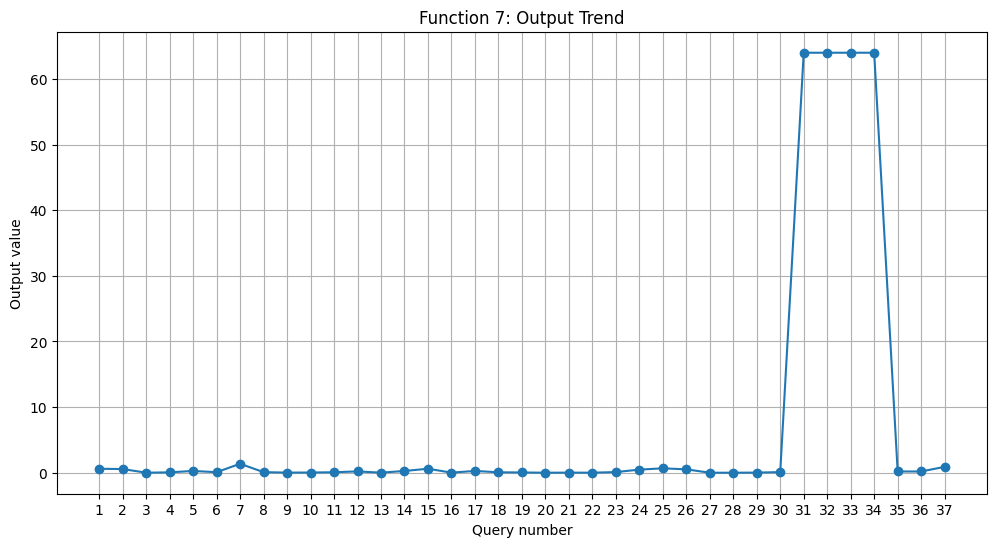

In [99]:
# ============================================================
# FUNCTION 7 — OUTPUT TREND
# ============================================================

query_numbers_7 = np.arange(1, len(y7) + 1)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers_7,
    y7,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Output value")
plt.title("Function 7: Output Trend")
plt.xticks(query_numbers_7)
plt.grid(True)
plt.show()

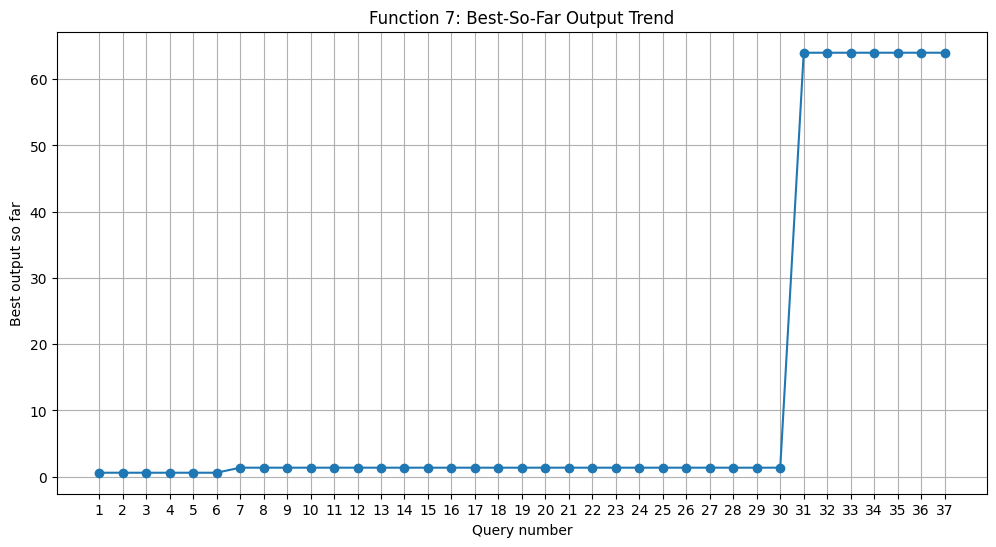

In [100]:
# ============================================================
# FUNCTION 7 — BEST-SO-FAR OUTPUT TREND
# ============================================================

best_so_far_7 = np.maximum.accumulate(y7)

plt.figure(figsize=(12, 6))

plt.plot(
    query_numbers_7,
    best_so_far_7,
    marker="o"
)

plt.xlabel("Query number")
plt.ylabel("Best output so far")
plt.title("Function 7: Best-So-Far Output Trend")
plt.xticks(query_numbers_7)
plt.grid(True)
plt.show()

In [101]:
# ============================================================
# FUNCTION 7 — BEST QUERY POINT
# ============================================================

best_index_7 = np.argmax(y7)

best_query_number_7 = best_index_7 + 1
best_input_7 = X7[best_index_7]
best_output_7 = y7[best_index_7]

print("Best query number:", best_query_number_7)
print("Best input point:", best_input_7)

for i, value in enumerate(best_input_7, start=1):
    print(f"Best x{i} value:", value)

print("Best output value:", best_output_7)

Best query number: 31
Best input point: [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best x1 value: 0.045091
Best x2 value: 0.528666
Best x3 value: 0.329265
Best x4 value: 0.10535
Best x5 value: 0.434667
Best x6 value: 0.641164
Best output value: 64.0


In [102]:
function_7_df.sort_values("Output", ascending=False).head(10)

,Query_Number,x1,x2,x3,x4,x5,x6,Output
30,31,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
33,34,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
32,33,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
31,32,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
6,7,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
36,37,0.121173,0.544849,0.282921,0.037758,0.374685,0.591179,0.899949
24,25,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142
14,15,0.148647,0.033943,0.728806,0.316066,0.021769,0.516918,0.611526
0,1,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,2,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753


              x1        x2        x3        x4        x5        x6    Output
x1      1.000000 -0.275744 -0.214764  0.167461  0.010591 -0.456482 -0.413246
x2     -0.275744  1.000000  0.055725 -0.077612  0.244282  0.203244  0.119492
x3     -0.214764  0.055725  1.000000  0.142756 -0.300991  0.053727 -0.081235
x4      0.167461 -0.077612  0.142756  1.000000  0.093659 -0.033317 -0.354625
x5      0.010591  0.244282 -0.300991  0.093659  1.000000  0.093603 -0.033008
x6     -0.456482  0.203244  0.053727 -0.033317  0.093603  1.000000  0.199104
Output -0.413246  0.119492 -0.081235 -0.354625 -0.033008  0.199104  1.000000


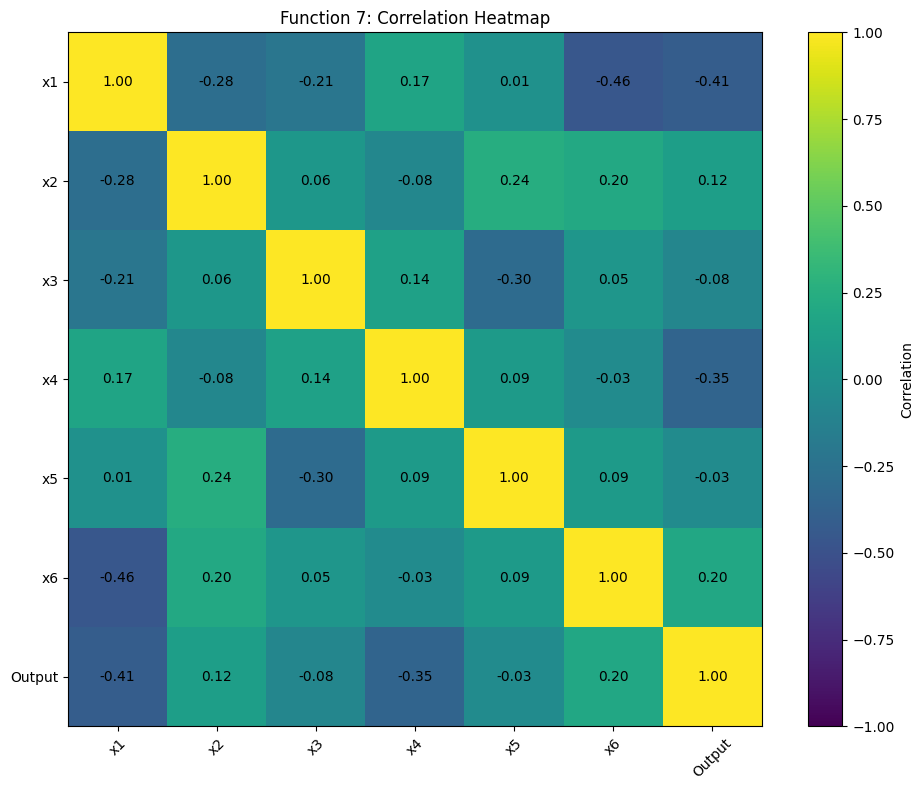

In [103]:
# ============================================================
# FUNCTION 7 — CORRELATION HEATMAP
# ============================================================

correlation_7 = function_7_df[
    ["x1", "x2", "x3", "x4", "x5", "x6", "Output"]
].corr()

print(correlation_7)

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_7,
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_7.columns)),
    correlation_7.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_7.columns)),
    correlation_7.columns
)

for i in range(len(correlation_7.columns)):
    for j in range(len(correlation_7.columns)):
        plt.text(
            j,
            i,
            f"{correlation_7.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Function 7: Correlation Heatmap")
plt.tight_layout()
plt.show()

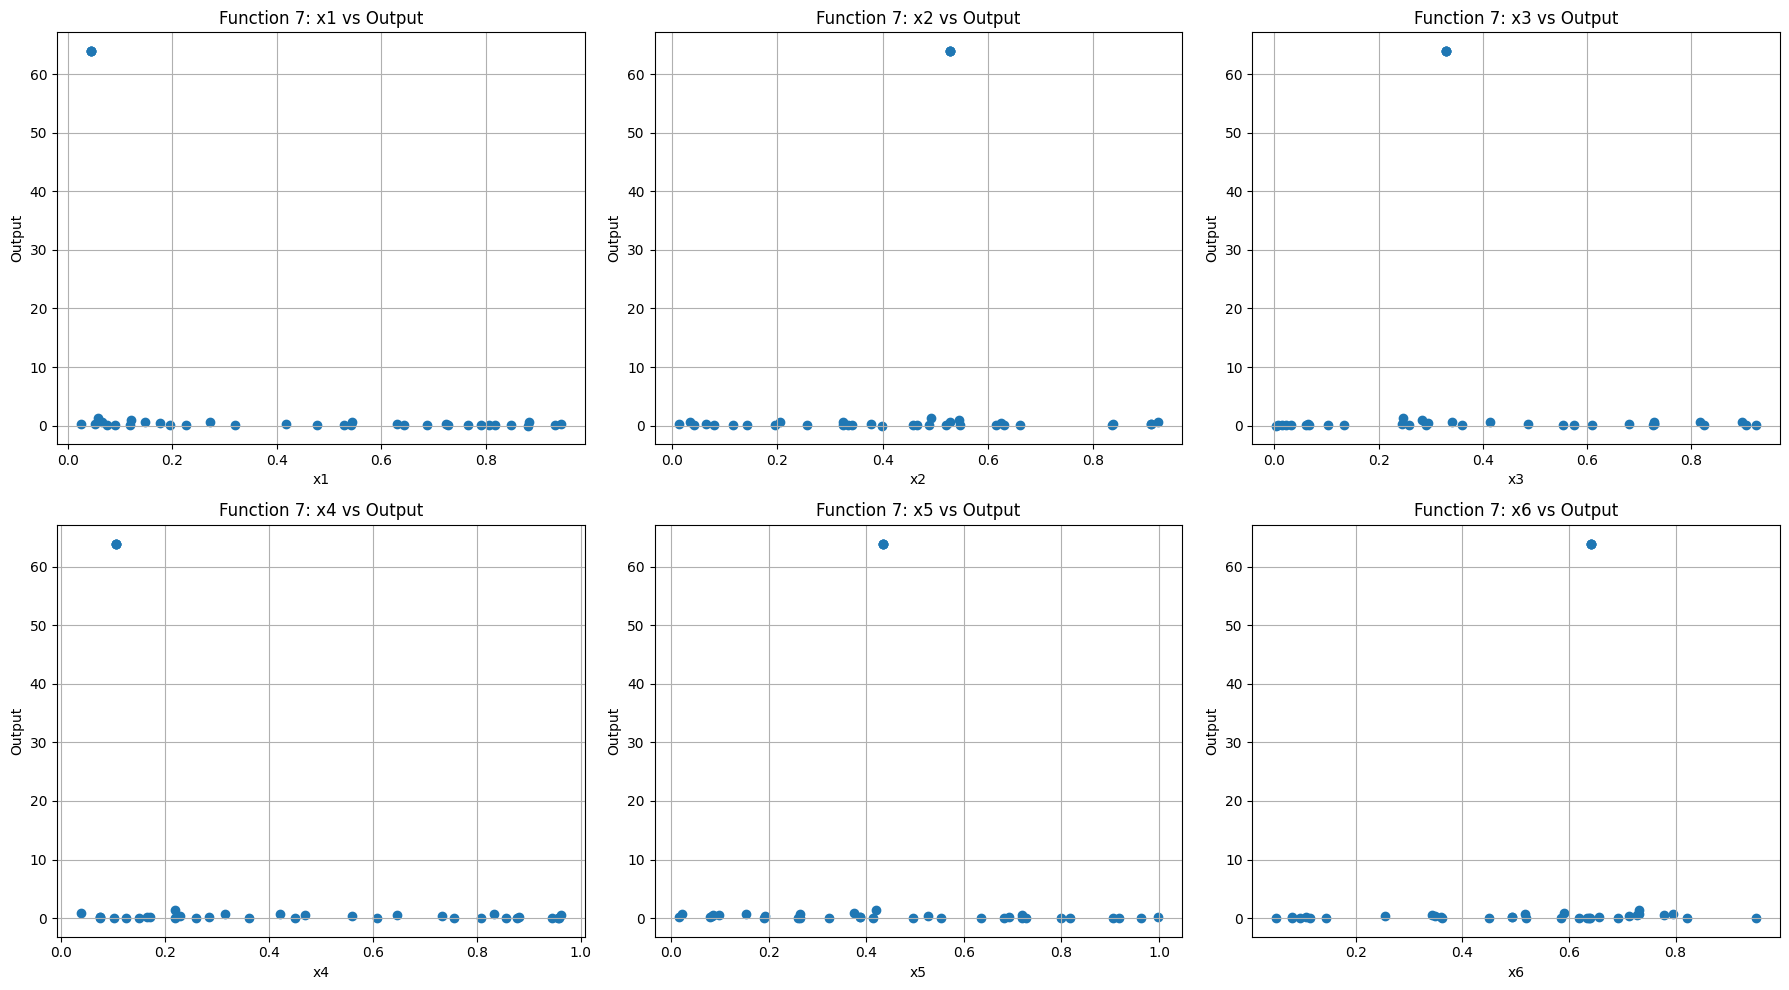

In [104]:
# ============================================================
# FUNCTION 7 — INPUT-OUTPUT SCATTER PLOTS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i in range(dim):

    axes[i].scatter(
        X7[:, i],
        y7
    )

    axes[i].set_xlabel(f"x{i + 1}")
    axes[i].set_ylabel("Output")
    axes[i].set_title(f"Function 7: x{i + 1} vs Output")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# FUNCTION 7 - INITIALISE AND FIT GP WITH COMBINED KERNEL
# ============================================================

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C


# Function 7 has 6 input dimensions
dim = 6

# Combined kernel settings
kernel_7 = C(
    constant_value=1.0,
    constant_value_bounds=(1e-3, 1e3)
) * Matern(
    length_scale=np.ones(dim) * 0.1,
    length_scale_bounds=(1e-2, 1.0),
    nu=2.5
) + WhiteKernel(
    noise_level=1e-4,
    noise_level_bounds=(1e-8, 1e-2)
)

# Gaussian Process surrogate model
gp_7 = GaussianProcessRegressor(
    kernel=kernel_7,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# Fit GP using Function 7 data
gp_7.fit(X7, y7)

print("Gaussian Process fitted successfully for Function 7.")
print("Learned kernel:")
print(gp_7.kernel_)

Gaussian Process fitted successfully for Function 7.
Learned kernel:
0.595**2 * Matern(length_scale=[1, 1, 1, 0.373, 0.16, 0.0203], nu=2.5) + WhiteKernel(noise_level=1e-08)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Convergenc

In [106]:
# ============================================================
# FUNCTION 7 — GENERATE CANDIDATE POINTS
# ============================================================

np.random.seed(42)

num_candidates = 10000

candidate_X7 = np.random.uniform(
    low=0.0,
    high=1.0,
    size=(num_candidates, dim)
)

print("Candidate shape:", candidate_X7.shape)

print("\nFirst five candidate points:")
print(candidate_X7[:5])

Candidate shape: (10000, 6)

First five candidate points:
[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501 0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497 0.18340451 0.30424224 0.52475643]
 [0.43194502 0.29122914 0.61185289 0.13949386 0.29214465 0.36636184]
 [0.45606998 0.78517596 0.19967378 0.51423444 0.59241457 0.04645041]]


In [107]:
# ============================================================
# FUNCTION 7 — UCB ACQUISITION FUNCTION
# ============================================================

kappa = 2.0

predicted_mean_7, predicted_std_7 = gp_7.predict(
    candidate_X7,
    return_std=True
)

ucb_7 = predicted_mean_7 + kappa * predicted_std_7

print("UCB calculated successfully for Function 7.")
print("Number of UCB scores:", len(ucb_7))

UCB calculated successfully for Function 7.
Number of UCB scores: 10000


In [108]:
# ============================================================
# FUNCTION 7 — SELECT NEXT QUERY POINT
# ============================================================

next_index_7 = np.argmax(ucb_7)

next_query_7 = candidate_X7[next_index_7]
next_mean_7 = predicted_mean_7[next_index_7]
next_std_7 = predicted_std_7[next_index_7]
next_ucb_7 = ucb_7[next_index_7]

print("FUNCTION 7 NEXT QUERY")
print("-" * 50)

print("Selected query point:")
print(next_query_7)

for i, value in enumerate(next_query_7, start=1):
    print(f"x{i}:", value)

print("\nGP predicted mean:", next_mean_7)
print("GP predicted uncertainty:", next_std_7)
print("UCB score:", next_ucb_7)

FUNCTION 7 NEXT QUERY
--------------------------------------------------
Selected query point:
[0.01617448 0.55896295 0.34858849 0.05076271 0.41774812 0.64403014]
x1: 0.016174477496196826
x2: 0.5589629511073055
x3: 0.34858848521063057
x4: 0.05076270881354272
x5: 0.4177481193181434
x6: 0.644030141171886

GP predicted mean: 62.00874616814497
GP predicted uncertainty: 3.4102520862717016
UCB score: 68.82925034068838


In [109]:
# ============================================================
# FUNCTION 7 — SUBMISSION FORMAT
# ============================================================

formatted_query_7 = "-".join(
    f"{value:.6f}" for value in next_query_7
)

print(f"Function 7 query: [{formatted_query_7}]")

Function 7 query: [0.016174-0.558963-0.348588-0.050763-0.417748-0.644030]


***FUNCTION 8 FOR WEEK 8***

In [110]:
# ============================================================
# FUNCTION 8 — LOAD DATA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

week_8_path = "/content/week_8_dataset"

f = 8
dim = 8

X8 = np.load(
    week_8_path + "/function_8_inputs.npy",
    allow_pickle=True
)

y8 = np.load(
    week_8_path + "/function_8_outputs.npy",
    allow_pickle=True
)

X8 = np.asarray(X8, dtype=float).reshape(-1, dim)
y8 = np.asarray(y8, dtype=float).reshape(-1)

print("Function 8 loaded successfully.")
print("X8 shape:", X8.shape)
print("y8 shape:", y8.shape)

Function 8 loaded successfully.
X8 shape: (46, 8)
y8 shape: (47,)


In [111]:
# ============================================================
# FUNCTION 8 — CHECK SHAPES AND MISSING VALUES
# ============================================================

print("Input shape:", X8.shape)
print("Output shape:", y8.shape)

print("\nNumber of input rows:", X8.shape[0])
print("Number of input variables:", X8.shape[1])
print("Number of output values:", len(y8))

print("\nMissing values in X8:", np.isnan(X8).sum())
print("Missing values in y8:", np.isnan(y8).sum())

print("\nInfinite values in X8:", np.isinf(X8).sum())
print("Infinite values in y8:", np.isinf(y8).sum())

if len(X8) == len(y8):
    print("\n✓ Every input has one corresponding output.")
else:
    print("\n⚠ Input and output sizes do not match.")

Input shape: (46, 8)
Output shape: (47,)

Number of input rows: 46
Number of input variables: 8
Number of output values: 47

Missing values in X8: 0
Missing values in y8: 0

Infinite values in X8: 0
Infinite values in y8: 0

⚠ Input and output sizes do not match.


In [112]:
y8 = y8[:len(X8)]

In [113]:
# ============================================================
# FUNCTION 8 — CREATE DATAFRAME
# ============================================================

function_8_df = pd.DataFrame({

    "Query_Number": np.arange(1, len(y8)+1),

    "x1": X8[:,0],
    "x2": X8[:,1],
    "x3": X8[:,2],
    "x4": X8[:,3],
    "x5": X8[:,4],
    "x6": X8[:,5],
    "x7": X8[:,6],
    "x8": X8[:,7],

    "Output": y8

})

function_8_df

,Query_Number,x1,x2,x3,x4,x5,x6,x7,x8,Output
0,1,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,2,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,3,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,4,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,5,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,6,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,7,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,8,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,9,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,10,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [114]:
# ============================================================
# FUNCTION 8 — SUMMARY STATISTICS
# ============================================================

print(function_8_df.describe())

print("\nMinimum Output:",np.min(y8))
print("Maximum Output:",np.max(y8))
print("Mean Output:",np.mean(y8))
print("Median Output:",np.median(y8))
print("Standard Deviation:",np.std(y8))

       Query_Number         x1         x2         x3         x4         x5  \
count     46.000000  46.000000  46.000000  46.000000  46.000000  46.000000   
mean      23.500000   0.489322   0.456880   0.479247   0.410641   0.504077   
std       13.422618   0.315616   0.301369   0.304312   0.273288   0.288814   
min        1.000000   0.006802   0.003419   0.022929   0.009043   0.009649   
25%       12.250000   0.212898   0.250583   0.243244   0.137653   0.251514   
50%       23.500000   0.476658   0.470746   0.418842   0.438626   0.491909   
75%       34.750000   0.778700   0.688062   0.729167   0.656450   0.736592   
max       46.000000   0.985945   0.973980   0.998885   0.902986   0.986902   

              x6         x7         x8     Output  
count  46.000000  46.000000  46.000000  46.000000  
mean    0.440133   0.530673   0.475300   8.015340  
std     0.281272   0.284351   0.277402   9.446036  
min     0.022113   0.035909   0.041956  -8.727516  
25%     0.230729   0.259932   0.29323

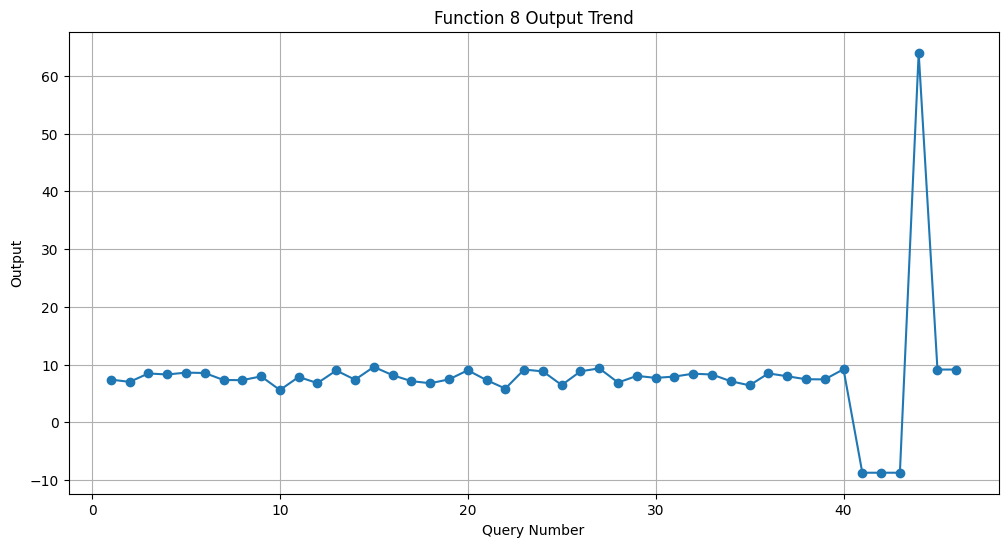

In [115]:
# ============================================================
# FUNCTION 8 — OUTPUT TREND
# ============================================================

query_numbers=np.arange(1,len(y8)+1)
plt.figure(figsize=(12,6))
plt.plot(query_numbers,y8,marker='o')
plt.xlabel("Query Number")
plt.ylabel("Output")
plt.title("Function 8 Output Trend")

plt.grid(True)
plt.show()

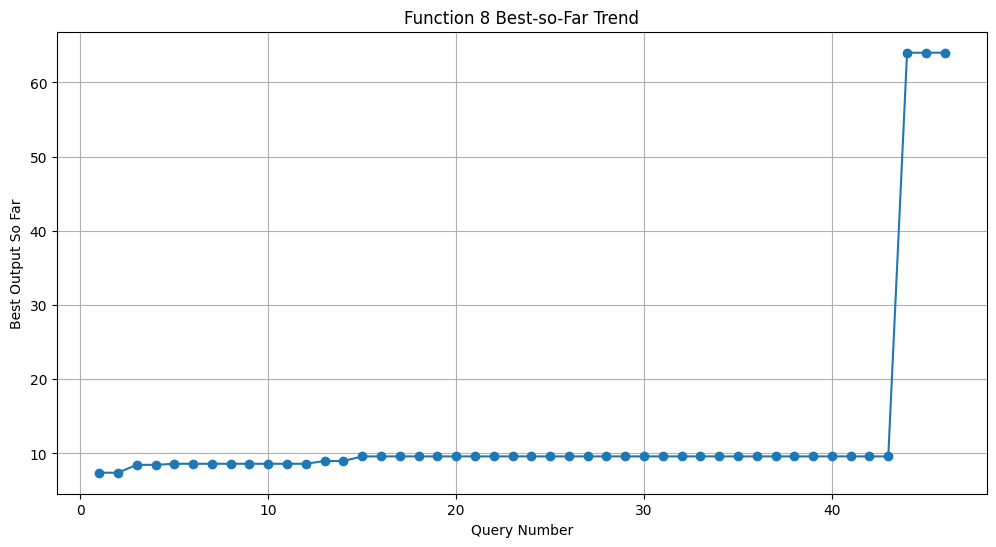

In [116]:
# ============================================================
# FUNCTION 8 — BEST SO FAR
# ============================================================

best_so_far=np.maximum.accumulate(y8)
plt.figure(figsize=(12,6))
plt.plot(query_numbers,best_so_far,marker='o')
plt.xlabel("Query Number")
plt.ylabel("Best Output So Far")
plt.title("Function 8 Best-so-Far Trend")

plt.grid(True)
plt.show()

In [117]:
# ============================================================
# FUNCTION 8 — BEST QUERY
# ============================================================

best_index=np.argmax(y8)
print("Best Query:",best_index+1)
print("\nBest Input")
print(X8[best_index])
print("\nBest Output")
print(y8[best_index])

Best Query: 44

Best Input
[0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]

Best Output
64.0


In [118]:
function_8_df.sort_values("Output", ascending=False).head(10)

,Query_Number,x1,x2,x3,x4,x5,x6,x7,x8,Output
43,44,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.110992,64.000000
14,15,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
26,27,0.192640,0.630677,0.416796,0.490529,0.796086,0.654567,0.276241,0.295518,9.344274
39,40,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005
22,23,0.145120,0.119328,0.420888,0.387609,0.155423,0.875172,0.510560,0.728611,9.141639
45,46,0.006802,0.833571,0.147083,0.461921,0.263530,0.887722,0.724982,0.315234,9.138609
44,45,0.022977,0.255313,0.963757,0.895383,0.716713,0.030436,0.083412,0.110992,9.138609
19,20,0.044329,0.013581,0.258198,0.577644,0.051280,0.158563,0.591030,0.077953,9.013075
12,13,0.143550,0.937415,0.232325,0.009043,0.414579,0.409325,0.553779,0.205841,8.976554
25,26,0.028947,0.028279,0.481372,0.613175,0.672660,0.022113,0.601483,0.524885,8.830745


              Query_Number        x1        x2        x3        x4        x5  \
Query_Number      1.000000 -0.108081 -0.070782 -0.350591  0.060449  0.477247   
x1               -0.108081  1.000000  0.168121  0.105149  0.102671  0.149983   
x2               -0.070782  0.168121  1.000000  0.099195 -0.130795 -0.047605   
x3               -0.350591  0.105149  0.099195  1.000000  0.230867 -0.142775   
x4                0.060449  0.102671 -0.130795  0.230867  1.000000 -0.151826   
x5                0.477247  0.149983 -0.047605 -0.142775 -0.151826  1.000000   
x6               -0.042036  0.189545  0.094642 -0.154309 -0.056901 -0.071417   
x7               -0.327589  0.264959 -0.032593 -0.022879  0.029790 -0.068137   
x8               -0.019624  0.232603 -0.207786  0.062355  0.352380 -0.049397   
Output            0.056276 -0.074102 -0.029527 -0.069851 -0.018743  0.004315   

                    x6        x7        x8    Output  
Query_Number -0.042036 -0.327589 -0.019624  0.056276  
x1       

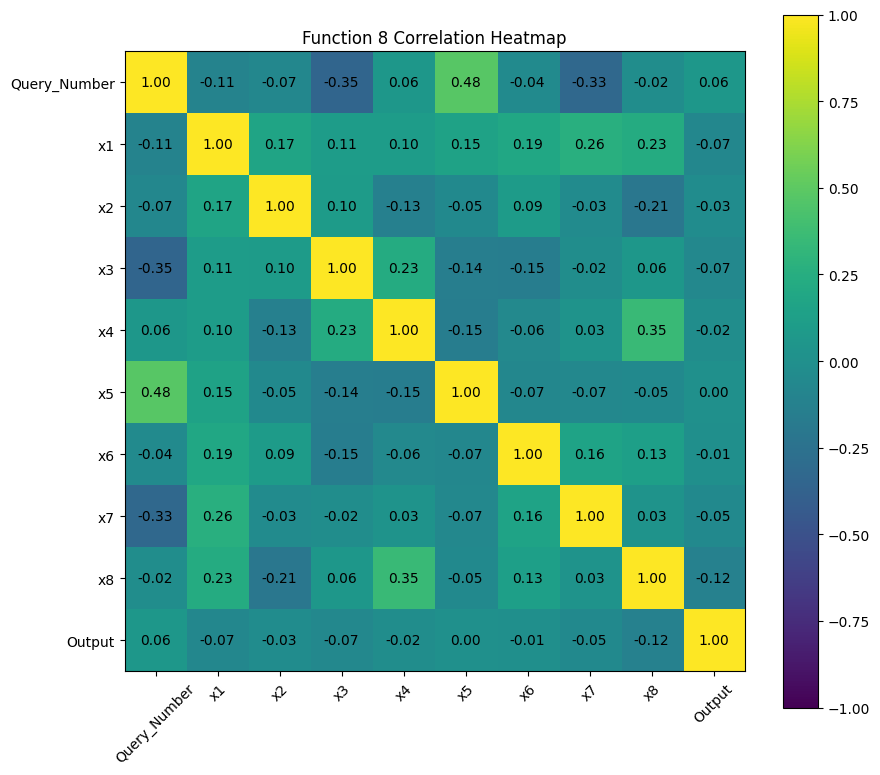

In [119]:
# ============================================================
# FUNCTION 8 — CORRELATION
# ============================================================
corr=function_8_df.corr()
print(corr)
plt.figure(figsize=(10,9))
plt.imshow(corr,vmin=-1,vmax=1)
plt.colorbar()
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Function 8 Correlation Heatmap")
plt.show()

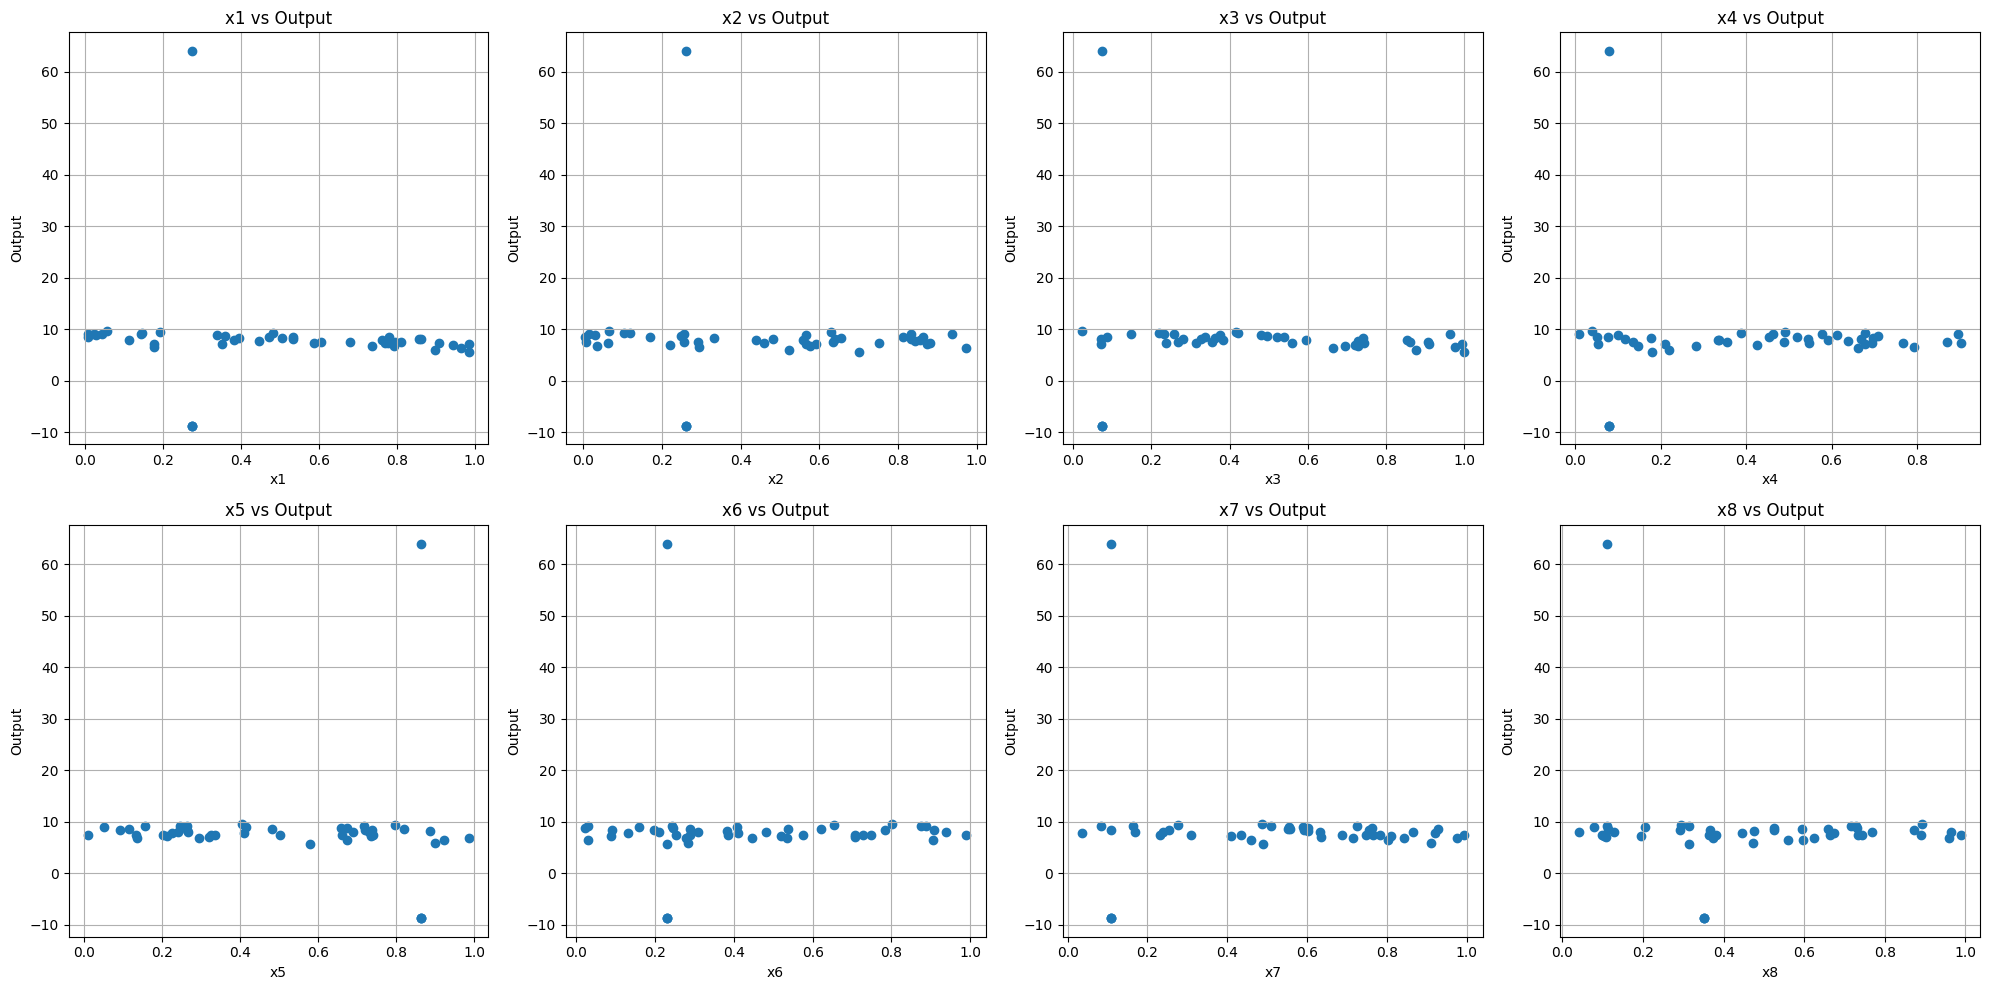

In [120]:
# ============================================================
# FUNCTION 8 — SCATTER PLOTS
# ============================================================

fig,axes=plt.subplots(2,4,figsize=(20,10))
axes=axes.flatten()
for i in range(dim):
    axes[i].scatter(X8[:,i],y8)
    axes[i].set_xlabel(f"x{i+1}")
    axes[i].set_ylabel("Output")
    axes[i].set_title(f"x{i+1} vs Output")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [121]:
# ============================================================
# FUNCTION 8 - INITIALISE AND FIT GP WITH COMBINED KERNEL
# ============================================================

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

# ------------------------------------------------------------
# Function 8 has 8 input dimensions
# ------------------------------------------------------------

dim = 8

# ------------------------------------------------------------
# Combined kernel settings
# ------------------------------------------------------------

kernel_8 = C(
    constant_value=1.0,
    constant_value_bounds=(1e-3, 1e3)
) * Matern(
    length_scale=np.ones(dim) * 0.1,
    length_scale_bounds=(1e-2, 1.0),
    nu=1.5
) + WhiteKernel(
    noise_level=1e-6,
    noise_level_bounds=(1e-8, 1e-2)
)

# ------------------------------------------------------------
# Gaussian Process surrogate model
# ------------------------------------------------------------

gp_8 = GaussianProcessRegressor(
    kernel=kernel_8,
    alpha=1e-6,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

# ------------------------------------------------------------
# Fit GP using Function 8 data
# ------------------------------------------------------------

gp_8.fit(X8, y8)

print("Gaussian Process fitted successfully for Function 8.")
print("Learned kernel:")
print(gp_8.kernel_)

Gaussian Process fitted successfully for Function 8.
Learned kernel:
0.994**2 * Matern(length_scale=[1, 1, 0.471, 1, 1, 1, 0.314, 0.0961], nu=1.5) + WhiteKernel(noise_level=1e-08)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Convergenc

In [122]:
# ============================================================
# FUNCTION 8 — GP SURROGATE
# ============================================================

kernel=RBF(
    length_scale=np.ones(dim),
    length_scale_bounds="fixed"
)
gp8=GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,
    normalize_y=True
)
gp8.fit(X8,y8)

print("GP fitted successfully.")
print(gp8.kernel_)

GP fitted successfully.
RBF(length_scale=[1, 1, 1, 1, 1, 1, 1, 1])


In [123]:
# ============================================================
# FUNCTION 8 — GENERATE CANDIDATES
# ============================================================

np.random.seed(42)
num_candidates=10000
candidate_X8=np.random.uniform(
    0,
    1,
    size=(num_candidates,dim)
)
print(candidate_X8.shape)
print(candidate_X8[:5])

(10000, 8)
[[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
  0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985 0.83244264 0.21233911
  0.18182497 0.18340451]
 [0.30424224 0.52475643 0.43194502 0.29122914 0.61185289 0.13949386
  0.29214465 0.36636184]
 [0.45606998 0.78517596 0.19967378 0.51423444 0.59241457 0.04645041
  0.60754485 0.17052412]
 [0.06505159 0.94888554 0.96563203 0.80839735 0.30461377 0.09767211
  0.68423303 0.44015249]]


In [124]:
# ============================================================
# FUNCTION 8 — UCB
# ============================================================

kappa=2
pred_mean,pred_std=gp8.predict(
    candidate_X8,
  return_std=True
)

ucb=pred_mean+kappa*pred_std
print("UCB completed.")

UCB completed.


In [125]:
# ============================================================
# FUNCTION 8 — NEXT QUERY
# ============================================================

best=np.argmax(ucb)
next_query=candidate_X8[best]
print("Recommended Query Point")
print(next_query)
print("\nPredicted Mean")
print(pred_mean[best])
print("\nPredicted Std")
print(pred_std[best])
print("\nUCB Score")
print(ucb[best])

Recommended Query Point
[0.71268282 0.19719269 0.12958454 0.33701781 0.7710443  0.10661309
 0.229839   0.00846442]

Predicted Mean
94.73030152748683

Predicted Std
2.4214286796815054

UCB Score
99.57315888684984


In [126]:
# ============================================================
# FUNCTION 8 — SUBMISSION FORMAT
# ============================================================

formatted = "-".join(f"{x:.6f}" for x in next_query)

print(f"Function 8 Query = [{formatted}]")

Function 8 Query = [0.712683-0.197193-0.129585-0.337018-0.771044-0.106613-0.229839-0.008464]
